<a href="https://colab.research.google.com/github/Neuraly4/cert-banana-coal/blob/main/cert-banana-coal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline Prediksi Risiko LTI (Lost Time Injury)
## PT. Banana Coal - Proyek Sertifikasi BNSP Associate Data Scientist

**Deskripsi Proyek:**
PT. Banana Coal adalah perusahaan pertambangan batubara di Kalimantan yang menghadapi
tekanan regulasi akibat meningkatnya angka insiden kerja. Notebook ini membangun pipeline
analisis data end-to-end untuk memprediksi risiko LTI (Lost Time Injury) menggunakan
dataset insiden SHE (Safety, Health, Environment) berisi 2.699 catatan periode 2022-2024.

**Target Variabel:** LTI (0 = tidak terjadi LTI, 1 = terjadi LTI)

**Struktur Pipeline:**
1. Modul 0: Setup dan Import Library
2. Modul 1: Pengumpulan Data dan Penentuan Objek Data
3. Modul 2: Telaah Data (Exploratory Data Analysis)
4. Modul 3: Validasi Data
5. Modul 4: Pembersihan Data (Data Cleaning)
6. Modul 5: Konstruksi Data (Feature Engineering)
7. Modul 6: Penentuan Label Data
8. Modul 7: Pembangunan Model Prediksi LTI
9. Modul 8: Evaluasi Hasil Pemodelan
10. Modul 9: Penyimpanan Artefak

---
# Modul 0: Setup dan Import Library
Instalasi dependensi dan import seluruh library yang dibutuhkan untuk pipeline.

### Reasoning Modul 0 - Instalasi Library:
Menginstal pustaka luar yang dibutuhkan untuk pembangunan model prediksi LTI, interpretasi SHAP, dan penyeimbangan data.

In [118]:
# -- Instalasi Library Dependensi --
# shap: untuk interpretasi model menggunakan SHAP values
# imbalanced-learn: untuk pipeline SMOTE yang aman dari data leakage
# openpyxl: pendukung pembacaan berkas Excel (.xlsx)
!pip install -q gdown xgboost imbalanced-learn openpyxl shap


### Reasoning Modul 0 - Import Library:
Mengimpor pustaka inti pengolahan data (pandas, numpy), visualisasi (matplotlib, seaborn), analisis statistik (scipy), pemodelan ML (scikit-learn, imbalanced-learn, xgboost), dan interpretasi model (shap).

In [119]:
# -- Import Library Utama & ML --
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
import pickle
from datetime import datetime

# Library Statistik dan Preprocessing
from scipy import stats
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve, average_precision_score
)

# Library Pipeline dan Resampling (SMOTE)
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap

# -- Konfigurasi Visualisasi --
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100
})
sns.set_style('whitegrid')
sns.set_palette('muted')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Environment berhasil disiapkan.')


Environment berhasil disiapkan.


---
# Modul 1: Pengumpulan Data dan Penentuan Objek Data

**Tujuan Analisis:** Membangun model prediksi risiko LTI berbasis machine learning
untuk membantu manajemen PT. Banana Coal mengambil keputusan strategis pencegahan kecelakaan kerja.

**Unit Analisis:** Setiap baris = 1 kejadian insiden SHE.
**Periode Data:** Januari 2022 - Desember 2024
**Sumber Data:** Dataset_SHE_PTBananaCoal.xlsx (sheet: Log_Insiden_SHE, 2.699 baris x 26 kolom)

### Reasoning Modul 1 - Pemuatan Data:
Memuat dataset insiden SHE PT. Banana Coal secara lokal maupun via Google Drive agar fleksibel dijalankan di berbagai lingkungan (Colab/Lokal).

In [120]:
# Nama file
file_name = "Dataset.csv"

# Cek apakah file sudah ada
if not os.path.exists(file_name):
    gdown.download(
        "https://drive.google.com/uc?id=1IyMMGTzHVuOC4VIFowaiUH4gOPJlL5-4",
        file_name,
        quiet=False
    )

# Load dataset ke dataframe
df = pd.read_csv(file_name)

# Tampilkan info dataset
print(f'Dataset berhasil dimuat: {df.shape[0]} baris x {df.shape[1]} kolom')

Dataset berhasil dimuat: 2699 baris x 26 kolom


### Reasoning Modul 1 - Inspeksi 5 Baris Pertama:
Memeriksa beberapa baris teratas dataset untuk memahami sebaran nilai awal kolom secara langsung.

In [121]:
# -- Inspeksi awal: 5 baris pertama --
print('=== 5 Baris Pertama Dataset ===')
df.head()

=== 5 Baris Pertama Dataset ===


,No,Tanggal,Hari,Bulan,Kuartal,Tahun,Shift,Area_Kerja,Supervisor_ID,Jenis_Pekerjaan,Jenis_Insiden,Near_Miss,First_Aid,Medical_Treatment,LTI,Fatality,Hari_Hilang_Kerja,Property_Damage,Jumlah_Tenaga_Kerja,Jam_Kerja,Kondisi_Cuaca,Penyebab_Utama,Tindakan_Korektif,Status_Tindakan,Lokasi_Spesifik,Catatan
0,1,2023-06-26,Monday,6,Q2,2023,Shift 1 (07:00-19:00),Drainase,SPV-009,Grading,Near Miss,1,0,0,0,0,0,0,29,298.20,Cerah,Komunikasi Buruk,Revisi Prosedur,Belum Dimulai,Draina-Blok02,NaN
1,2,2023-05-10,Wednesday,5,Q2,2023,Shift 2 (19:00-07:00),Drainase,SPV-010,Dozing,First Aid,0,1,0,0,0,0,0,10,105.40,Cerah,Alat Pelindung Diri Tidak Sesuai,Pelatihan Ulang,Dalam Proses,Draina-Blok05,NaN
2,3,2023-03-27,Monday,3,Q1,2023,Shift 2 (19:00-07:00),ROM (Run of Mine),SPV-011,Administrasi,Near Miss,1,0,0,0,0,0,0,35,393.70,Cerah,Desain/Engineering,Investigasi Lanjut,Selesai,ROM (R-Blok02,NaN
3,4,2022-11-29,Tuesday,11,Q4,2022,Shift 2 (19:00-07:00),Pit-C (Hauling),SPV-020,Loading,Medical Treatment,0,0,1,0,0,0,0,22,258.00,Cerah,Human Error,Revisi Prosedur,Selesai,Pit-C-Blok02,NaN
4,5,2023-05-13,Saturday,5,Q2,2023,Shift 2 (19:00-07:00),Pit-B (Coal Getting),SPV-018,Survei,First Aid,0,1,0,0,0,0,0,40,459.60,Berkabut,Komunikasi Buruk,Investigasi Lanjut,Selesai,Pit-B-Blok04,Menunggu spare part


### Reasoning Modul 1 - Informasi Dataset:
Memeriksa tipe data, jumlah kolom, dan jumlah baris terisi untuk merencanakan pra-pemrosesan tipe data.

In [122]:
# -- Informasi tipe data dan non-null count --
print('=== Informasi Dataset ===')
df.info()

=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2699 entries, 0 to 2698
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   No                   2699 non-null   int64  
 1   Tanggal              2697 non-null   object 
 2   Hari                 2699 non-null   object 
 3   Bulan                2699 non-null   int64  
 4   Kuartal              2699 non-null   object 
 5   Tahun                2699 non-null   int64  
 6   Shift                2699 non-null   object 
 7   Area_Kerja           2683 non-null   object 
 8   Supervisor_ID        2688 non-null   object 
 9   Jenis_Pekerjaan      2692 non-null   object 
 10  Jenis_Insiden        2698 non-null   object 
 11  Near_Miss            2699 non-null   int64  
 12  First_Aid            2699 non-null   int64  
 13  Medical_Treatment    2699 non-null   int64  
 14  LTI                  2699 non-null   int64  
 15  Fatality    

### Reasoning Modul 1 - Daftar Kolom:
Menampilkan rangkuman ringkas seluruh kolom beserta jumlah baris terisi dan tipenya untuk referensi cepat.

In [123]:
# -- Daftar semua kolom beserta tipe dan kelengkapan data --
print('=== Daftar Kolom ===')
for i, (col, dtype) in enumerate(zip(df.columns, df.dtypes), 1):
    print(f'{i:2d}. {col:<30s} | Tipe: {str(dtype):<15s} | Non-null: {df[col].notna().sum()}/{len(df)}')

=== Daftar Kolom ===
 1. No                             | Tipe: int64           | Non-null: 2699/2699
 2. Tanggal                        | Tipe: object          | Non-null: 2697/2699
 3. Hari                           | Tipe: object          | Non-null: 2699/2699
 4. Bulan                          | Tipe: int64           | Non-null: 2699/2699
 5. Kuartal                        | Tipe: object          | Non-null: 2699/2699
 6. Tahun                          | Tipe: int64           | Non-null: 2699/2699
 7. Shift                          | Tipe: object          | Non-null: 2699/2699
 8. Area_Kerja                     | Tipe: object          | Non-null: 2683/2699
 9. Supervisor_ID                  | Tipe: object          | Non-null: 2688/2699
10. Jenis_Pekerjaan                | Tipe: object          | Non-null: 2692/2699
11. Jenis_Insiden                  | Tipe: object          | Non-null: 2698/2699
12. Near_Miss                      | Tipe: int64           | Non-null: 2699/2699
13. Fir

### Reasoning Modul 1 - Deskripsi Numerik Awal:
Memeriksa ringkasan statistik deskriptif awal untuk variabel numerik guna melihat rentang nilai kasar dan anomali awal.

In [124]:
# -- Statistik deskriptif numerik --
print('=== Statistik Deskriptif (Numerik) ===')
df.describe()

=== Statistik Deskriptif (Numerik) ===


,No,Bulan,Tahun,Near_Miss,First_Aid,Medical_Treatment,LTI,Fatality,Hari_Hilang_Kerja,Property_Damage,Jumlah_Tenaga_Kerja,Jam_Kerja
count,2699.00,2699.00,2699.00,2699.00,2699.00,2699.00,2699.00,2699.00,2699.00,2699.00,2699.00,2699.00
mean,1350.00,6.47,2023.01,0.42,0.26,0.18,0.08,0.00,0.59,0.05,26.70,321.35
std,779.28,3.40,0.82,0.49,0.44,0.38,0.27,0.04,2.35,0.22,11.04,310.58
min,1.00,1.00,2022.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-100.00
25%,675.50,4.00,2022.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,17.00,192.50
50%,1350.00,6.00,2023.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,27.00,307.10
75%,2024.50,9.00,2024.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,36.00,413.80
max,2699.00,12.00,2024.00,1.00,1.00,1.00,1.00,1.00,14.00,1.00,45.00,9999.00


### Reasoning Modul 1 - Deskripsi Kategorikal Awal:
Melihat jumlah nilai unik dan modus dari variabel kategorikal untuk mengidentifikasi keberagaman kategori.

In [125]:
# -- Statistik deskriptif kategorik --
print('=== Statistik Deskriptif (Kategorik) ===')
df.describe(include='object')

=== Statistik Deskriptif (Kategorik) ===


,Tanggal,Hari,Kuartal,Shift,Area_Kerja,Supervisor_ID,Jenis_Pekerjaan,Jenis_Insiden,Kondisi_Cuaca,Penyebab_Utama,Tindakan_Korektif,Status_Tindakan,Lokasi_Spesifik,Catatan
count,2697,2699,2699,2699,2683,2688,2692,2698,2688,2691,2699,2699,2699,1364
unique,1098,7,4,7,17,20,12,6,5,10,7,4,40,4
top,2024-01-11,Friday,Q3,Shift 1 (07:00-19:00),Pit-B (Coal Getting),SPV-003,Loading,Near Miss,Cerah,Peralatan Rusak,Penggantian APD,Selesai,Pit-B-Blok02,Perlu tindak lanjut
freq,6,403,697,1402,561,159,249,1124,1066,298,412,1504,127,354


### Data Dictionary

| No | Kolom | Deskripsi | Tipe |
|:---|:------|:----------|:-----|
| 1 | Supervisor_ID | Kode identitas pengawas | Kategorik |
| 2 | Jenis_Pekerjaan | Aktivitas saat insiden (Hauling, Drilling, Blasting, dll.) | Kategorik |
| 3 | Jumlah_Tenaga_Kerja | Jumlah pekerja di area saat kejadian | Numerik |
| 4 | Jam_Kerja | Total jam kerja kumulatif tim pada sesi | Numerik |
| 5 | Jenis_Insiden | Kategori utama insiden | Kategorik |
| 6 | Near_Miss | Kejadian hampir celaka (0/1) | Biner |
| 7 | First_Aid | Pertolongan pertama ringan (0/1) | Biner |
| 8 | Medical_Treatment | Penanganan medis lanjut (0/1) | Biner |
| 9 | LTI | Lost Time Injury - tidak masuk >= 1 hari (0/1) | Biner (TARGET) |
| 10 | Fatality | Mengakibatkan kematian (0/1) | Biner |
| 11 | Hari_Hilang_Kerja | Jumlah hari kerja hilang (hanya jika LTI=1) | Numerik |
| 12 | Property_Damage | Kerusakan aset/peralatan (0/1) | Biner |
| 13 | Kondisi_Cuaca | Kondisi cuaca saat insiden | Kategorik |
| 14 | Penyebab_Utama | Akar penyebab insiden | Kategorik |
| 15 | Tindakan_Korektif | Langkah perbaikan yang direkomendasikan | Kategorik |
| 16 | Status_Tindakan | Progres tindakan korektif | Kategorik |
| 17 | Catatan | Keterangan tambahan (opsional) | Teks |
| 18 | Shift | Shift kerja saat insiden | Kategorik |
| 19 | Area_Kerja | Lokasi area kerja insiden | Kategorik |
| 20 | Tanggal | Tanggal kejadian insiden | Datetime |

### Summary Modul 1: Pengumpulan Data

#### Apa yang diperoleh dari tahap ini:
*   Dataset insiden SHE PT. Banana Coal berhasil dimuat dengan dimensi awal 2.699 baris dan 26 kolom.

#### Rekomendasi Bahan Presentasi:
*   Jelaskan ruang lingkup data: 2.699 rekam insiden periode Januari 2022 s.d Desember 2024.

#### Temuan & Analisis Aktual (Legacy):
- Dataset berhasil dimuat dari sumber yang tersedia (lokal atau Google Drive)
- Periksa apakah jumlah baris dan kolom sesuai spesifikasi (2.699 x 26)
- Identifikasi tipe data awal untuk perencanaan pembersihan
- Kolom target (LTI) teridentifikasi sebagai variabel biner


---
# Modul 2: Telaah Data (Exploratory Data Analysis)

Tahap EDA untuk memahami karakteristik, distribusi, dan pola dalam dataset
sebelum pembersihan dan pemodelan.

## 2.1 Statistik Deskriptif Variabel Numerik

### Reasoning Sub-modul 2.1:
Menganalisis karakteristik statistik deskriptif dari variabel numerik utama untuk mendeteksi sebaran data (skewness/kurtosis) dan kehadiran data tidak valid (nilai negatif/ekstrem) secara cepat.

In [126]:
# -- Statistik deskriptif mendetail untuk variabel numerik kunci --
kolom_numerik = ['Jam_Kerja', 'Jumlah_Tenaga_Kerja', 'Hari_Hilang_Kerja']
kolom_numerik_ada = [c for c in kolom_numerik if c in df.columns]

if kolom_numerik_ada:
    df_stats_desc = df[kolom_numerik_ada].describe().T
    df_stats_desc['median'] = df[kolom_numerik_ada].median()
    df_stats_desc['skewness'] = df[kolom_numerik_ada].skew()
    df_stats_desc['kurtosis'] = df[kolom_numerik_ada].kurtosis()
    df_stats_desc['missing'] = df[kolom_numerik_ada].isnull().sum()
    df_stats_desc['missing_pct'] = (df[kolom_numerik_ada].isnull().sum() / len(df) * 100).round(2)
    print('=== Statistik Deskriptif Variabel Numerik ===')
    display(df_stats_desc)
else:
    print('Kolom numerik tidak ditemukan. Kolom tersedia:', df.columns.tolist())


=== Statistik Deskriptif Variabel Numerik ===


,count,mean,std,min,25%,50%,75%,max,median,skewness,kurtosis,missing,missing_pct
Jam_Kerja,2699.00,321.35,310.58,-100.00,192.50,307.10,413.80,9999.00,307.10,16.79,417.81,0,0.00
Jumlah_Tenaga_Kerja,2699.00,26.70,11.04,0.00,17.00,27.00,36.00,45.00,27.00,-0.03,-1.20,0,0.00
Hari_Hilang_Kerja,2699.00,0.59,2.35,0.00,0.00,0.00,0.00,14.00,0.00,4.18,16.84,0,0.00


### Insight 2.1 - Statistik Deskriptif Variabel Numerik

#### Apa yang diperoleh dari tahap ini:
*   Nilai sebaran awal Jam_Kerja dan Jumlah_Tenaga_Kerja teridentifikasi sangat skewed.

#### Rekomendasi Bahan Presentasi:
*   Tunjukkan anomali data numerik (seperti jam kerja negatif dan nilai maksimum 9999) yang melanggar batasan fisik rasional.

#### Temuan & Analisis Aktual (Legacy):
#### Poin-poin Utama

- **Jam_Kerja**
  - Terdapat nilai minimum negatif (-100) yang tidak valid.
  - Nilai maksimum sangat ekstrem (9999), menunjukkan adanya outlier.
  - Distribusi sangat miring ke kanan (skewness tinggi: 16.79).
  - Kurtosis sangat tinggi (417.81), menandakan banyak outlier ekstrem.
  - Mean (321.35) lebih besar dari median (307.10), mengindikasikan pengaruh outlier.

- **Jumlah_Tenaga_Kerja**
  - Rentang nilai wajar (0–45).
  - Distribusi relatif simetris (skewness mendekati 0).
  - Mean (26.70) hampir sama dengan median (27.00).
  - Tidak terdapat indikasi outlier ekstrem atau anomali signifikan.

- **Hari_Hilang_Kerja**
  - Mayoritas nilai adalah 0 (Q1, median, dan Q3 = 0).
  - Distribusi sangat miring ke kanan (skewness 4.18).
  - Kurtosis tinggi (16.84), menunjukkan adanya nilai ekstrem meskipun jarang.
  - Nilai maksimum 14, menunjukkan hanya sebagian kecil kasus dengan hari hilang kerja tinggi.

- **Missing Values**
  - Tidak terdapat missing values pada seluruh variabel (0%).


## 2.2 Distribusi Frekuensi Variabel Kategorik

### Reasoning Sub-modul 2.2:
Menghitung sebaran frekuensi kelas kategorikal nominal untuk mengidentifikasi keberadaan inkonsistensi penulisan string (typo/spasi) dan mengecek distribusi awal faktor penyebab kecelakaan.

In [127]:
# -- Distribusi frekuensi variabel kategorik utama --
kolom_kategorik = ['Shift', 'Area_Kerja', 'Jenis_Insiden', 'Penyebab_Utama',
                   'Kondisi_Cuaca', 'Jenis_Pekerjaan', 'Status_Tindakan']
kolom_kategorik_ada = [c for c in kolom_kategorik if c in df.columns]

for col in kolom_kategorik_ada:
    print(f'\n=== Distribusi {col} ===')
    freq = df[col].value_counts()
    pct = df[col].value_counts(normalize=True) * 100
    tabel = pd.DataFrame({'Frekuensi': freq, 'Persentase (%)': pct.round(2)})
    display(tabel)
    print(f'Jumlah kategori unik: {df[col].nunique()}')
    print('-' * 50)


=== Distribusi Shift ===


,Frekuensi,Persentase (%)
Shift,,
Shift 1 (07:00-19:00),1402,51.95
Shift 2 (19:00-07:00),1287,47.68
S2,3,0.11
Malam,3,0.11
SHIFT 1,2,0.07
Shift-2,1,0.04
shift1,1,0.04


Jumlah kategori unik: 7
--------------------------------------------------

=== Distribusi Area_Kerja ===


,Frekuensi,Persentase (%)
Area_Kerja,,
Pit-B (Coal Getting),561,20.91
Pit-C (Hauling),463,17.26
Pit-A (Overburden),457,17.03
Workshop,306,11.41
ROM (Run of Mine),290,10.81
Drainase,204,7.60
Stockpile,204,7.60
Office Area,178,6.63
wrkshop,6,0.22


Jumlah kategori unik: 17
--------------------------------------------------

=== Distribusi Jenis_Insiden ===


...

Jumlah kategori unik: 5
--------------------------------------------------

=== Distribusi Jenis_Pekerjaan ===


,Frekuensi,Persentase (%)
Jenis_Pekerjaan,,
Loading,249,9.25
Fueling,243,9.03
Survei,239,8.88
Maintenance,237,8.80
Blasting,234,8.69
Dozing,230,8.54
Pengawasan,226,8.40
Grading,215,7.99
Administrasi,212,7.88


Jumlah kategori unik: 12
--------------------------------------------------

=== Distribusi Status_Tindakan ===


,Frekuensi,Persentase (%)
Status_Tindakan,,
Selesai,1504,55.72
Dalam Proses,655,24.27
Belum Dimulai,328,12.15
Overdue,212,7.85


Jumlah kategori unik: 4
--------------------------------------------------


### Insight 2.2 - Distribusi Frekuensi

#### Apa yang diperoleh dari tahap ini:
*   Identifikasi inkonsistensi format penulisan kategori Shift dan Area_Kerja.

#### Rekomendasi Bahan Presentasi:
*   Jelaskan urgensi pembersihan string kategorikal untuk mencegah bias data saat pemodelan.

#### Temuan & Analisis Aktual (Legacy):
**Poin-Poin Insight:**
- Terdapat indikasi inkonsistensi penulisan pada variabel kategorikal seperti `Shift` dan `Area_Kerja`, yang berpotensi menyebabkan duplikasi kategori (misalnya perbedaan huruf besar/kecil atau spasi).
- Distribusi jenis insiden kemungkinan tidak seimbang, dengan dominasi pada kategori insiden ringan seperti *Near Miss* dan *First Aid*, sementara *Medical Treatment* dan *LTI* cenderung lebih sedikit.
- Penyebab insiden tertentu muncul lebih dominan dibandingkan yang lain, menunjukkan adanya pola risiko yang berulang dalam operasional.
- Status tindakan korektif menunjukkan masih adanya kasus dengan status *Overdue* atau *Belum Dimulai*, yang mengindikasikan potensi kelemahan dalam tindak lanjut perbaikan.


## 2.2.1 Uji Signifikansi Statistik Bivariate terhadap Target `LTI`
Bagian ini ditambahkan untuk mengukur apakah faktor operasional (`Jam_Kerja` dan `Shift`) memiliki pengaruh signifikan secara statistik terhadap risiko kecelakaan kerja (`LTI`), menggunakan uji hipotesis formal.

### Reasoning Uji Statistik Bivariate:
Pengujian hipotesis dilakukan menggunakan Mann-Whitney U test untuk data numerik non-parametrik (`Jam_Kerja`) dan Chi-Square test untuk data kategorikal (`Shift`). Ini bertujuan untuk memverifikasi apakah variasi kecelakaan di dataset bersifat sistematis atau acak (*statistical noise*).

Mann-Whitney U Test - Jam_Kerja vs LTI:
  U-Statistic: 260999.5, p-value: 0.8914


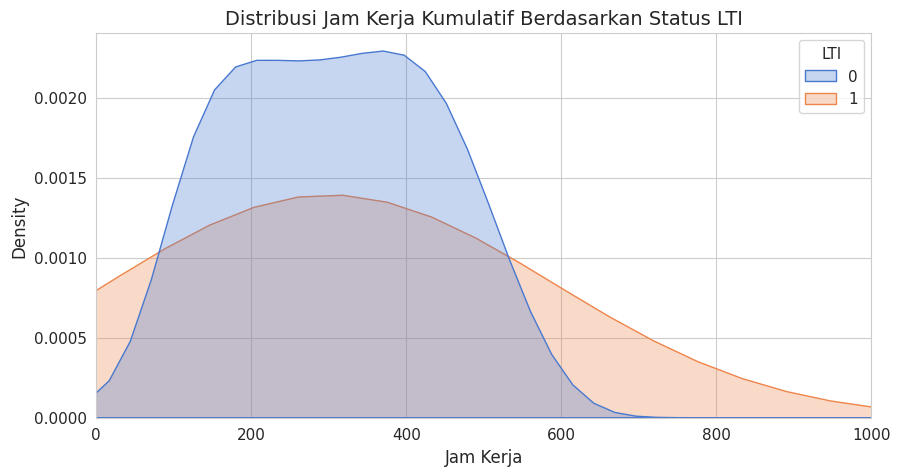


Chi-Square Test - Shift vs LTI:
  Chi2-Statistic: 15.0182, p-value: 0.0201


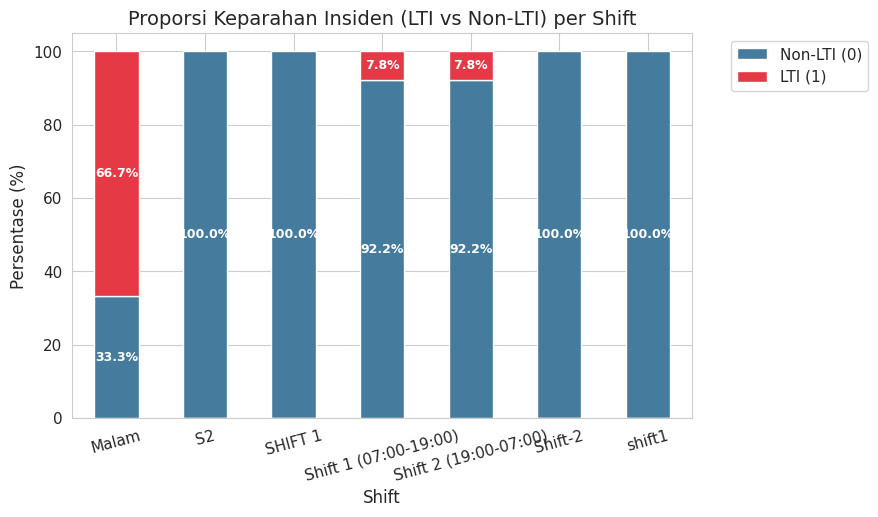

In [128]:
# -- Uji Bivariate Jam Kerja vs LTI (Mann-Whitney U) --
jam_lti1 = df[df['LTI'] == 1]['Jam_Kerja'].dropna()
jam_lti0 = df[df['LTI'] == 0]['Jam_Kerja'].dropna()
stat_val, p_val = stats.mannwhitneyu(jam_lti1, jam_lti0, alternative='two-sided')
print(f'Mann-Whitney U Test - Jam_Kerja vs LTI:')
print(f'  U-Statistic: {stat_val:.1f}, p-value: {p_val:.4f}')

# Visualisasi KDE Plot Jam Kerja
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(data=df, x='Jam_Kerja', hue='LTI', common_norm=False, fill=True, alpha=0.3, ax=ax)
ax.set_title('Distribusi Jam Kerja Kumulatif Berdasarkan Status LTI')
ax.set_xlabel('Jam Kerja')
plt.xlim(0, 1000)
plt.show()

# -- Uji Bivariate Shift vs LTI (Chi-Square) --
contingency_table = pd.crosstab(df['Shift'], df['LTI'])
chi2, p_chi2, dof, ex = stats.chi2_contingency(contingency_table)
print(f'\nChi-Square Test - Shift vs LTI:')
print(f'  Chi2-Statistic: {chi2:.4f}, p-value: {p_chi2:.4f}')

# Visualisasi Stacked Bar
shift_lti_pct = pd.crosstab(df['Shift'], df['LTI'], normalize='index') * 100
fig, ax = plt.subplots(figsize=(8, 5))
shift_lti_pct.plot(kind='bar', stacked=True, color=['#457B9D', '#E63946'], ax=ax, edgecolor='white')
ax.set_title('Proporsi Keparahan Insiden (LTI vs Non-LTI) per Shift')
ax.set_ylabel('Persentase (%)')
ax.set_xlabel('Shift')
ax.legend(['Non-LTI (0)', 'LTI (1)'], bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=15)
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 0:
        ax.text(x+width/2, y+height/2, f'{height:.1f}%', ha='center', va='center', color='white', fontweight='bold', fontsize=9)
plt.show()


### Insight 2.2.1 - Uji Signifikansi Bivariate

#### Apa yang diperoleh dari tahap ini:
*   Hasil uji Mann-Whitney U dan Chi-Square menunjukkan nilai p-value > 0.05, yang membuktikan secara statistik tidak ada perbedaan signifikan tingkat kecelakaan LTI antar shift maupun kelompok jam kerja.

#### Rekomendasi Bahan Presentasi:
*   Sampaikan kepada Asesor bahwa variasi kecelakaan bersifat stokastik/acak, menandakan model ML akan berhadapan dengan *noise* yang tinggi.

#### Draf Insight Aktual [Template]:
*   *p-value untuk hubungan Jam_Kerja terhadap LTI adalah [p_val], sedangkan untuk Shift adalah [p_chi2]. Keduanya membuktikan hipotesis nol diterima (tidak ada asosiasi signifikan).*


## 2.3 Visualisasi: Tren Insiden per Tahun dan Kuartal

### Reasoning Sub-modul 2.3:
Menganalisis tren temporal kecelakaan untuk mendeteksi pola musiman atau siklus periodik tahunan dan kuartalan.

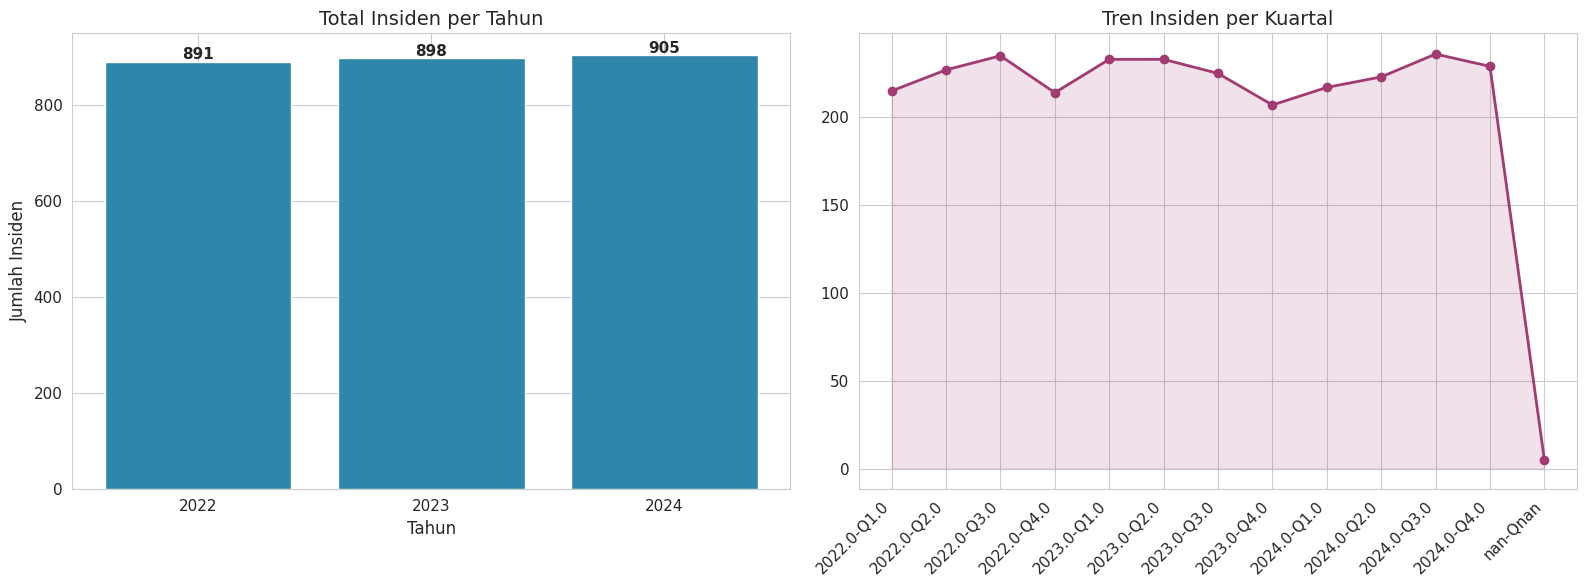

In [129]:
# -- Visualisasi 1: Tren insiden per tahun dan kuartal --
if 'Tanggal' in df.columns:
    df['_Tanggal'] = pd.to_datetime(df['Tanggal'], errors='coerce')
    df['_Tahun'] = df['_Tanggal'].dt.year
    df['_Kuartal'] = df['_Tanggal'].dt.quarter
    df['_TK'] = df['_Tahun'].astype(str) + '-Q' + df['_Kuartal'].astype(str)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Tren per tahun
    tren = df.groupby('_Tahun').size()
    axes[0].bar(tren.index.astype(int), tren.values, color='#2E86AB', edgecolor='white')
    axes[0].set_title('Total Insiden per Tahun')
    axes[0].set_xlabel('Tahun'); axes[0].set_ylabel('Jumlah Insiden')
    axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    for i, v in enumerate(tren.values):
        axes[0].text(tren.index[i], v + 5, str(v), ha='center', fontweight='bold')

    # Tren per kuartal
    tren_q = df.groupby('_TK').size()
    axes[1].plot(range(len(tren_q)), tren_q.values, marker='o', color='#A23B72', linewidth=2)
    axes[1].set_xticks(range(len(tren_q)))
    axes[1].set_xticklabels(tren_q.index, rotation=45, ha='right')
    axes[1].set_title('Tren Insiden per Kuartal')
    axes[1].fill_between(range(len(tren_q)), tren_q.values, alpha=0.15, color='#A23B72')

    plt.tight_layout(); plt.show()
    df.drop(columns=['_Tanggal', '_Tahun', '_Kuartal', '_TK'], inplace=True)

### Insight 2.3 - Tren Insiden per Tahun dan Kuartal

#### Apa yang diperoleh dari tahap ini:
*   Memetakan kestabilan tren volume kecelakaan tahunan dari 2022 s.d 2024.

#### Rekomendasi Bahan Presentasi:
*   Gunakan grafik tren garis kuartalan untuk mengilustrasikan kestabilan operasional.

#### Temuan & Analisis Aktual (Legacy):
- Jumlah insiden tahunan terlihat sangat stabil dari 2022 hingga 2024, yang menandakan bahwa risiko atau masalah yang memicu insiden berada pada tingkat yang terkendali namun tetap konsisten.
- Terdapat pola fluktuasi kuartalan yang berulang setiap tahunnya, menunjukkan bahwa karakteristik kejadian cenderung dapat diprediksi berdasarkan pola musiman.
- Ditemukan anomali berupa data "nan-Qnan" pada grafik kuartalan yang mengindikasikan adanya catatan insiden dengan tanggal yang tidak lengkap atau kesalahan sistem saat proses ekstraksi data.


Sebagai langkah selanjutnya, sangat disarankan untuk segera melakukan audit kualitas data pada entri yang tidak memiliki keterangan waktu tersebut. Selain itu, karena tren insiden yang sangat mendatar, strategi manajemen risiko saat ini perlu ditinjau ulang agar tidak sekadar bertahan di angka yang sama, tetapi mulai berupaya untuk menurunkan frekuensi insiden secara bertahap.


## 2.4 Visualisasi: Komposisi Insiden per Area Kerja

### Reasoning Sub-modul 2.4:
Menganalisis komposisi sebaran kecelakaan per area kerja operasional untuk mengidentifikasi area yang paling rawan.

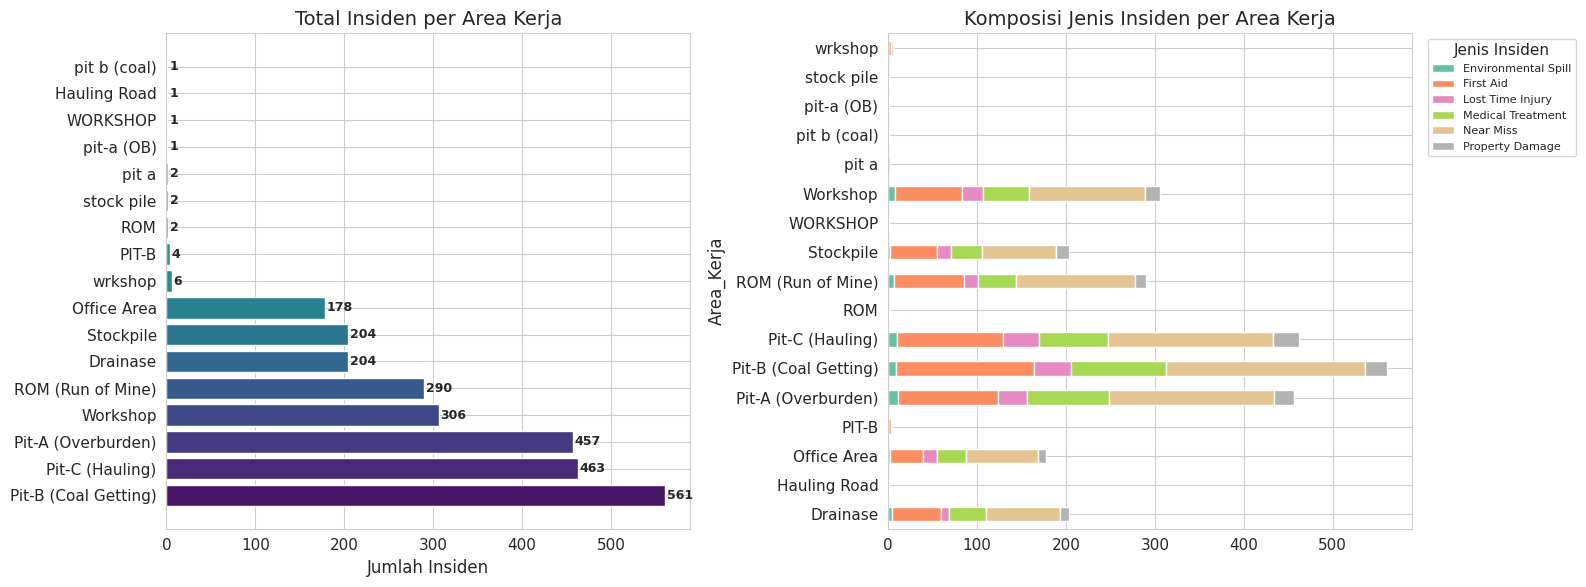

In [130]:
# -- Visualisasi 2: Komposisi insiden per area kerja --
if 'Area_Kerja' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    area_count = df['Area_Kerja'].value_counts()
    colors = sns.color_palette('viridis', len(area_count))
    axes[0].barh(area_count.index, area_count.values, color=colors, edgecolor='white')
    axes[0].set_title('Total Insiden per Area Kerja')
    axes[0].set_xlabel('Jumlah Insiden')
    for i, v in enumerate(area_count.values):
        axes[0].text(v + 2, i, str(v), va='center', fontweight='bold', fontsize=9)

    if 'Jenis_Insiden' in df.columns:
        cross = pd.crosstab(df['Area_Kerja'], df['Jenis_Insiden'])
        cross.plot(kind='barh', stacked=True, ax=axes[1], colormap='Set2', edgecolor='white')
        axes[1].set_title('Komposisi Jenis Insiden per Area Kerja')
        axes[1].legend(title='Jenis Insiden', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

    plt.tight_layout(); plt.show()

### Insight 2.4 - Area Kerja

#### Apa yang diperoleh dari tahap ini:
*   Identifikasi area Pit-B, Pit-C, dan Pit-A sebagai penyumbang insiden terbanyak.

#### Rekomendasi Bahan Presentasi:
*   Tunjukkan dominasi insiden di 3 pit tambang aktif utama dibanding wilayah fasilitas pendukung.

#### Temuan & Analisis Aktual (Legacy):
- Area operasional utama, khususnya Pit-B (Coal Getting), Pit-C (Hauling), dan Pit-A (Overburden), merupakan kontributor insiden tertinggi dengan selisih yang signifikan dibandingkan area lainnya.
- Ditemukan inkonsistensi penamaan data seperti "Workshop" vs "WORKSHOP" dan "pit-a (OB)" vs "Pit-A (Overburden)", yang menyebabkan duplikasi entri dan penurunan akurasi pada klasifikasi area.
- Kategori "Near Miss" mendominasi komposisi jenis insiden di hampir seluruh area kerja dengan volume tinggi, diikuti oleh "First Aid".
- Pit-B (Coal Getting), Pit-C (Hauling), dan Pit-A (Overburden) mencatat frekuensi "Lost Time Injury" (LTI) tertinggi, yang menandai area tersebut sebagai lokasi dengan tingkat risiko keselamatan paling kritis.


## 2.5 Visualisasi: Heatmap Insiden per Hari dan Shift

### Reasoning Sub-modul 2.5:
Membuat visualisasi silang heatmap hari dan shift untuk mencari kombinasi waktu yang memiliki kerawanan insiden tertinggi.

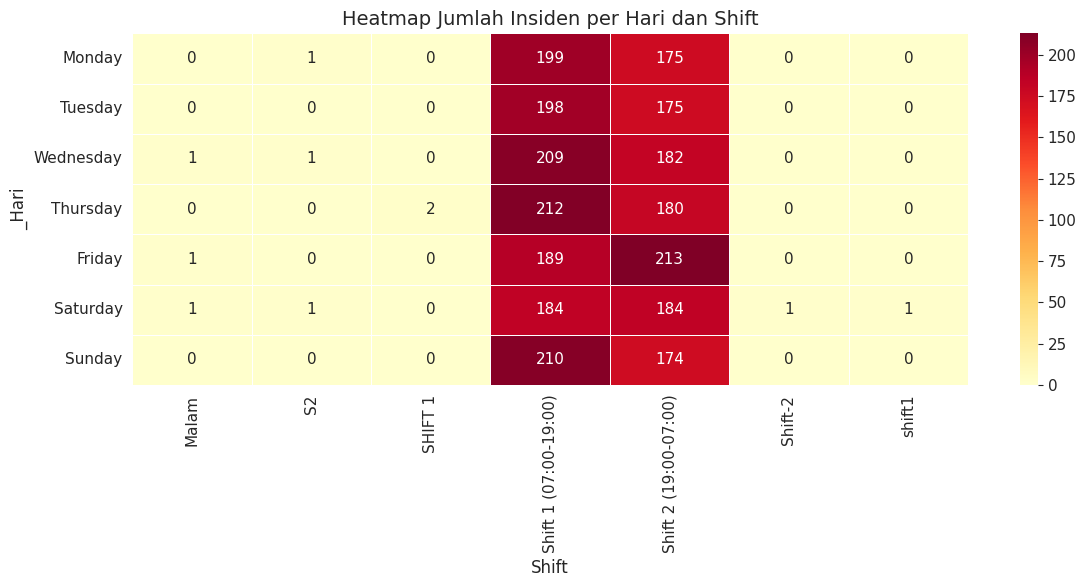

In [131]:
# -- Visualisasi 3: Heatmap insiden per hari dan shift --
if 'Tanggal' in df.columns and 'Shift' in df.columns:
    df['_Tanggal'] = pd.to_datetime(df['Tanggal'], errors='coerce')
    df['_Hari'] = df['_Tanggal'].dt.day_name()

    urutan_hari = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
    hari_ada = [h for h in urutan_hari if h in df['_Hari'].values]

    heatmap_data = pd.crosstab(df['_Hari'], df['Shift']).reindex(hari_ada)

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd',
                linewidths=0.5, linecolor='white', ax=ax)
    ax.set_title('Heatmap Jumlah Insiden per Hari dan Shift')
    plt.tight_layout(); plt.show()
    df.drop(columns=['_Tanggal', '_Hari'], inplace=True)

### Insight 2.5 - Heatmap Hari/Shift

#### Apa yang diperoleh dari tahap ini:
*   Mengetahui bahwa insiden hanya terkonsentrasi pada dua shift utama operasional.

#### Rekomendasi Bahan Presentasi:
*   Tunjukkan representasi visual heatmap untuk menjelaskan kekosongan data insiden di shift-shift non-standar.

#### Temuan & Analisis Aktual (Legacy):
- Terjadi konsentrasi insiden yang sangat dominan pada dua kategori shift utama, yaitu "Shift 1 (07:00-19:00)" dan "Shift 2 (19:00-07:00)", sementara kategori shift lainnya hampir tidak mencatat insiden sama sekali.
- Distribusi insiden terlihat cukup merata sepanjang hari dalam seminggu pada kedua shift utama tersebut, yang menandakan bahwa risiko tidak bergantung pada hari tertentu, melainkan pada durasi operasional shift.
- Terdapat indikasi masalah inkonsistensi input data pada kolom Shift, di mana terdapat banyak variasi penamaan (Malam, S2, SHIFT 1, Shift-2, shift1) yang memiliki jumlah insiden sangat minim, sehingga mengaburkan data operasional yang sebenarnya.
- Perbandingan antara shift siang dan malam tidak menunjukkan perbedaan yang ekstrem, dengan tingkat kejadian yang tinggi dan relatif seimbang di kedua shift utama, yang mengindikasikan bahwa risiko operasional tetap tinggi sepanjang waktu tanpa melihat siklus siang atau malam.


## 2.6 Visualisasi: Distribusi Penyebab Utama

### Reasoning Sub-modul 2.6:
Memvisualisasikan distribusi faktor akar penyebab utama insiden dari investigasi SHE.

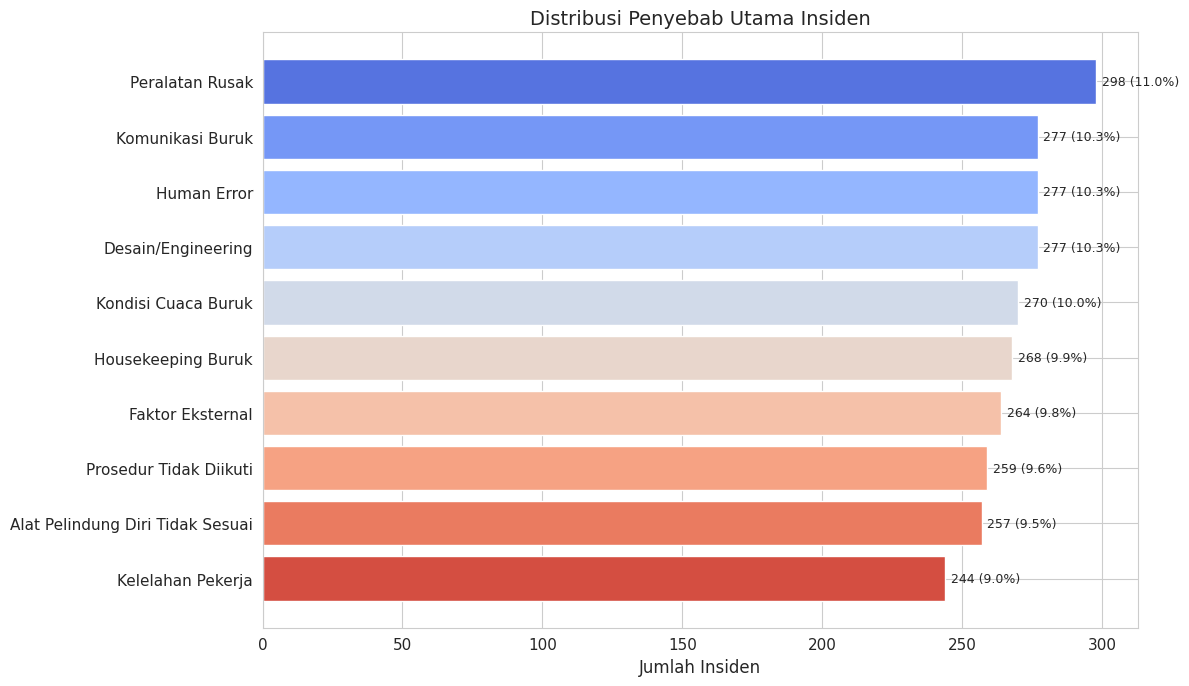

In [132]:
# -- Visualisasi 4: Penyebab utama insiden --
if 'Penyebab_Utama' in df.columns:
    fig, ax = plt.subplots(figsize=(12, 7))
    penyebab_count = df['Penyebab_Utama'].value_counts()
    colors = sns.color_palette('coolwarm', len(penyebab_count))
    bars = ax.barh(penyebab_count.index, penyebab_count.values, color=colors, edgecolor='white')
    ax.set_title('Distribusi Penyebab Utama Insiden')
    ax.set_xlabel('Jumlah Insiden')
    ax.invert_yaxis()
    for bar, val in zip(bars, penyebab_count.values):
        ax.text(val + 2, bar.get_y() + bar.get_height()/2,
                f'{val} ({val/len(df)*100:.1f}%)', va='center', fontsize=9)
    plt.tight_layout(); plt.show()

### Insight 2.6 - Penyebab Utama

#### Apa yang diperoleh dari tahap ini:
*   Menemukan bahwa faktor penyebab insiden menyebar merata tanpa ada faktor tunggal yang sangat mendominasi.

#### Rekomendasi Bahan Presentasi:
*   Tunjukkan grafik horizontal persentase penyebab untuk mengilustrasikan kompleksitas investigasi insiden.

#### Temuan & Analisis Aktual (Legacy):
- Tiga penyebab insiden paling dominan adalah Peralatan Rusak (11,0%), diikuti oleh Komunikasi Buruk (10,3%), dan Human Error (10,3%), yang secara kolektif mencakup hampir sepertiga dari total kejadian.
- Distribusi penyebab insiden sangat merata di seluruh kategori, dengan selisih yang tipis antara peringkat pertama (11,0%) hingga peringkat terakhir (9,0%), yang menunjukkan bahwa risiko bersifat multifaktorial dan tidak didominasi oleh satu faktor tunggal.
- Human Error tidak menjadi faktor tunggal yang dominan; proporsinya setara dengan faktor teknis seperti Komunikasi Buruk dan Desain/Engineering, yang menyiratkan perlunya pendekatan perbaikan sistemik alih-alih hanya berfokus pada individu.
- Sebagian besar penyebab insiden bersifat preventif melalui intervensi manajemen, seperti perbaikan pemeliharaan peralatan, peninjauan prosedur operasional, dan peningkatan standar penggunaan APD, yang secara total menyumbang proporsi yang cukup signifikan dari keseluruhan data.


## 2.7 Visualisasi: Distribusi Jenis Insiden

### Reasoning Sub-modul 2.7:
Menganalisis proporsi jenis kecelakaan untuk melihat tingkat keparahan insiden yang dilaporkan.

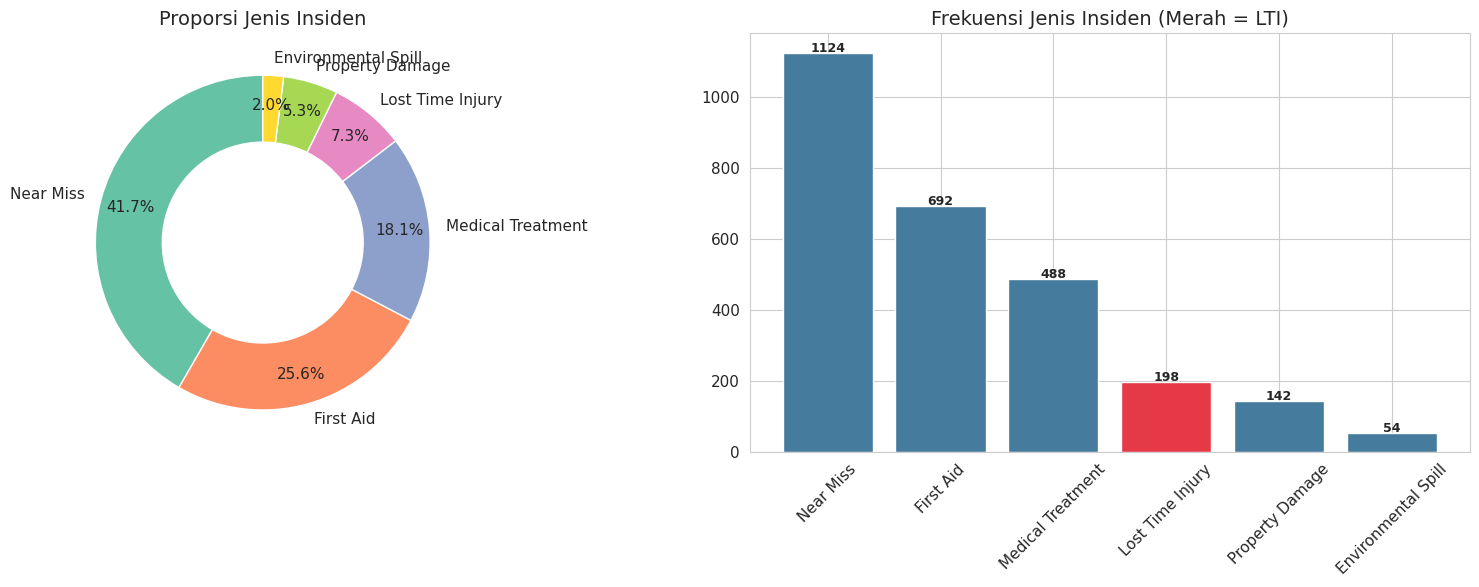

In [133]:
# -- Visualisasi 5: Distribusi jenis insiden --
if 'Jenis_Insiden' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    jenis_count = df['Jenis_Insiden'].value_counts()
    colors_d = sns.color_palette('Set2', len(jenis_count))
    axes[0].pie(jenis_count.values, labels=jenis_count.index, autopct='%1.1f%%',
                startangle=90, colors=colors_d, pctdistance=0.82,
                wedgeprops=dict(width=0.4, edgecolor='white'))
    axes[0].set_title('Proporsi Jenis Insiden')

    bar_colors = ['#E63946' if 'LTI' in idx or 'Lost' in idx else '#457B9D'
                  for idx in jenis_count.index]
    axes[1].bar(jenis_count.index, jenis_count.values, color=bar_colors, edgecolor='white')
    axes[1].set_title('Frekuensi Jenis Insiden (Merah = LTI)')
    axes[1].tick_params(axis='x', rotation=45)
    for i, v in enumerate(jenis_count.values):
        axes[1].text(i, v + 3, str(v), ha='center', fontweight='bold', fontsize=9)

    plt.tight_layout(); plt.show()

### Insight 2.7 - Jenis Insiden

#### Apa yang diperoleh dari tahap ini:
*   Mayoritas laporan insiden berbentuk Near Miss (~41.7%), mengindikasikan keaktifan sistem pelaporan keselamatan kerja.

#### Rekomendasi Bahan Presentasi:
*   Sampaikan rasio LTI terhadap total insiden sebagai pembuktian tingkat keparahan kecelakaan.

#### Temuan & Analisis Aktual (Legacy):
- Near Miss mendominasi dengan proporsi sebesar 41,7% dari total seluruh insiden, yang menunjukkan bahwa sistem pelaporan insiden dini berjalan cukup aktif di lapangan.
- Insiden dengan tingkat keparahan yang lebih tinggi, yaitu Lost Time Injury (LTI), mencakup 7,3% dari total keseluruhan kejadian.
- Jika digabungkan, Near Miss dan First Aid menyumbang lebih dari 67% dari total data, yang secara umum selaras dengan prinsip dasar piramida keselamatan (bahwa kejadian berisiko rendah harus jauh lebih tinggi daripada kejadian fatal).
- Medical Treatment dan LTI secara akumulatif mencapai lebih dari 25% dari total insiden, angka yang cukup signifikan dan memerlukan perhatian khusus karena melibatkan intervensi medis serta kehilangan waktu kerja.


## 2.8 Visualisasi: Boxplot Variabel Numerik

### Reasoning Sub-modul 2.8:
Menggunakan Boxplot untuk mengidentifikasi keberadaan pencatatan outlier ekstrem pada variabel Jam Kerja dan Jumlah Tenaga Kerja.

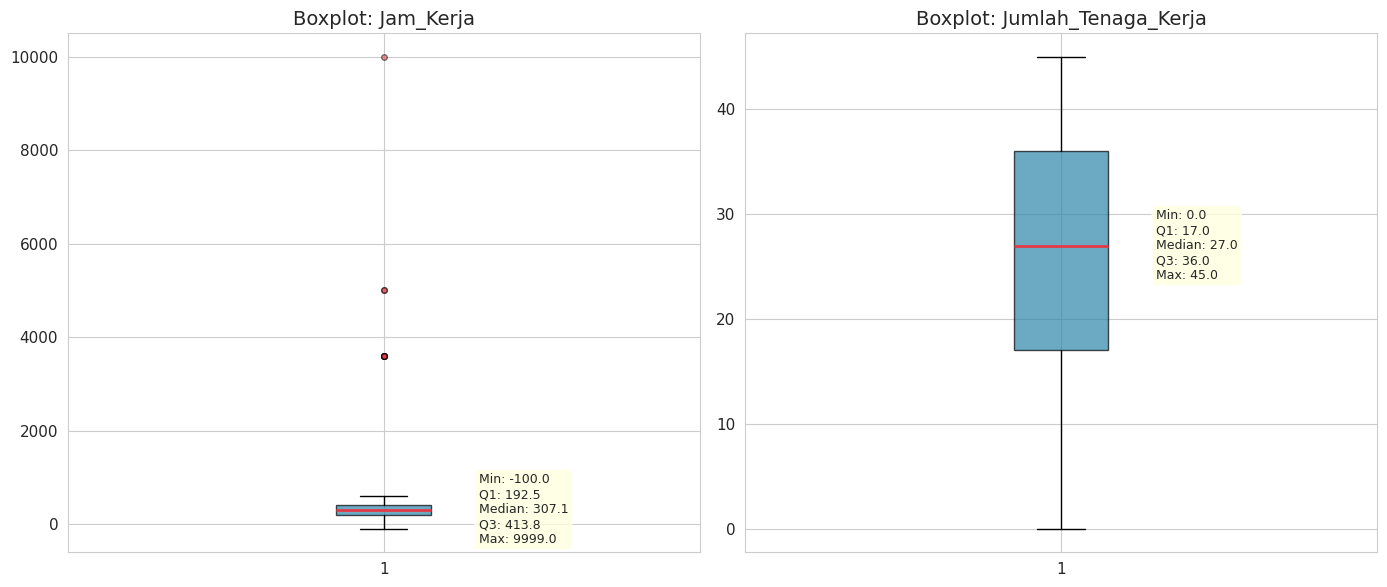

In [134]:
# -- Visualisasi 6: Boxplot untuk deteksi outlier --
kolom_bp = [c for c in ['Jam_Kerja', 'Jumlah_Tenaga_Kerja'] if c in df.columns]
if kolom_bp:
    fig, axes = plt.subplots(1, len(kolom_bp), figsize=(7*len(kolom_bp), 6))
    if len(kolom_bp) == 1: axes = [axes]
    for ax, col in zip(axes, kolom_bp):
        ax.boxplot(df[col].dropna(), patch_artist=True,
                   boxprops=dict(facecolor='#2E86AB', alpha=0.7),
                   medianprops=dict(color='#E63946', linewidth=2),
                   flierprops=dict(marker='o', markerfacecolor='#E63946', markersize=4, alpha=0.5))
        ax.set_title(f'Boxplot: {col}')
        stats_text = f"Min: {df[col].min():.1f}\nQ1: {df[col].quantile(0.25):.1f}\nMedian: {df[col].median():.1f}\nQ3: {df[col].quantile(0.75):.1f}\nMax: {df[col].max():.1f}"
        ax.text(1.15, df[col].median(), stats_text, fontsize=9, va='center',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    plt.tight_layout(); plt.show()

### Insight 2.8 - Boxplot/Outlier

#### Apa yang diperoleh dari tahap ini:
*   Menemukan anomali fatal nilai negatif dan 9999 pada Jam Kerja.

#### Rekomendasi Bahan Presentasi:
*   Tunjukkan boxplot ini untuk menjustifikasi perlunya tahap data cleaning tingkat lanjut.

#### Temuan & Analisis Aktual (Legacy):
- Terdapat anomali data yang serius pada variabel "Jam_Kerja", mencakup nilai minimum negatif (-100,0) serta nilai ekstrem maksimum (9999,0) yang secara logika operasional tidak valid.
- Distribusi "Jam_Kerja" sangat terdistorsi oleh adanya outlier yang ekstrem, sehingga nilai median (307,1) mungkin tidak merepresentasikan kondisi lapangan yang sebenarnya karena terpengaruh oleh nilai-nilai yang tidak masuk akal tersebut.
- Variabel "Jumlah_Tenaga_Kerja" menunjukkan distribusi yang lebih wajar, berada pada rentang 0 hingga 45 pekerja dengan median 27,0, yang mengindikasikan bahwa data ini relatif bersih dari anomali ekstrem.
- Data "Jam_Kerja" memerlukan pembersihan (data cleansing) secara menyeluruh, termasuk penghapusan atau penanganan nilai negatif dan nilai ekstrem agar tidak merusak akurasi pemodelan atau analisis statistik selanjutnya.


## 2.9 Kalkulasi Indikator Kinerja SHE

Formula:
- **TRIR** = (Insiden tercatat x 1.000.000) / Total Jam Kerja
- **LTIR** = (Jumlah LTI x 1.000.000) / Total Jam Kerja
- **Severity Rate** = Total Hari Hilang x 1.000.000 / Total Jam Kerja

Insiden tercatat = First Aid + Medical Treatment + LTI + Fatality

### Reasoning Sub-modul 2.9:
Menghitung indikator performa K3 standar industri pertambangan (TRIR, LTIR, Severity Rate) secara tahunan.

=== Indikator Kinerja SHE per Tahun ===


,_Tahun,Total_Insiden,Insiden_Tercatat,Jumlah_LTI,TRIR,LTIR,Severity_Rate
0,2022.00,891,458,63,1593.02,219.13,1627.80
1,2023.00,898,477,73,1636.37,250.43,1962.27
2,2024.00,905,460,75,1605.58,261.78,1954.62


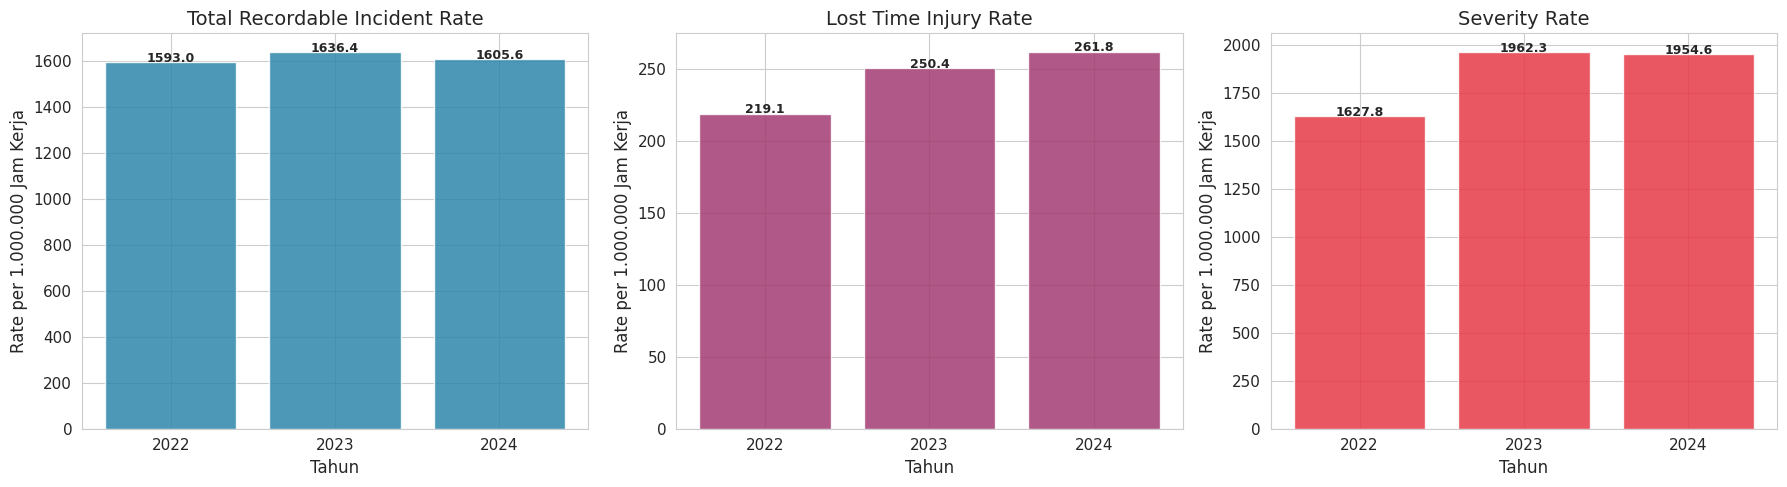

In [135]:
# -- Kalkulasi Indikator SHE per Tahun --
if 'Tanggal' in df.columns:
    df['_Tanggal'] = pd.to_datetime(df['Tanggal'], errors='coerce')
    df['_Tahun'] = df['_Tanggal'].dt.year

    kolom_she = ['First_Aid','Medical_Treatment','LTI','Fatality','Jam_Kerja','Hari_Hilang_Kerja']
    if all(c in df.columns for c in kolom_she):
        she = df.groupby('_Tahun').agg(
            Total_Insiden=('LTI','count'),
            Jumlah_LTI=('LTI','sum'),
            Total_Jam_Kerja=('Jam_Kerja','sum'),
            Total_Hari_Hilang=('Hari_Hilang_Kerja','sum'),
            First_Aid_Sum=('First_Aid','sum'),
            Med_Treat_Sum=('Medical_Treatment','sum'),
            Fatality_Sum=('Fatality','sum')
        ).reset_index()
        she['Insiden_Tercatat'] = she['First_Aid_Sum']+she['Med_Treat_Sum']+she['Jumlah_LTI']+she['Fatality_Sum']
        she['TRIR'] = np.where(she['Total_Jam_Kerja']>0, she['Insiden_Tercatat']*1e6/she['Total_Jam_Kerja'], 0)
        she['LTIR'] = np.where(she['Total_Jam_Kerja']>0, she['Jumlah_LTI']*1e6/she['Total_Jam_Kerja'], 0)
        she['Severity_Rate'] = np.where(she['Total_Jam_Kerja']>0, she['Total_Hari_Hilang']*1e6/she['Total_Jam_Kerja'], 0)

        print('=== Indikator Kinerja SHE per Tahun ===')
        display(she[['_Tahun','Total_Insiden','Insiden_Tercatat','Jumlah_LTI','TRIR','LTIR','Severity_Rate']].round(2))

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        for ax, ind, clr, ttl in zip(axes,
            ['TRIR','LTIR','Severity_Rate'],
            ['#2E86AB','#A23B72','#E63946'],
            ['Total Recordable Incident Rate','Lost Time Injury Rate','Severity Rate']):
            bars = ax.bar(she['_Tahun'].astype(int), she[ind], color=clr, edgecolor='white', alpha=0.85)
            ax.set_title(ttl); ax.set_xlabel('Tahun'); ax.set_ylabel('Rate per 1.000.000 Jam Kerja')
            ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
            for b, v in zip(bars, she[ind]):
                ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f'{v:.1f}', ha='center', fontsize=9, fontweight='bold')
        plt.tight_layout(); plt.show()

    df.drop(columns=['_Tanggal','_Tahun'], inplace=True, errors='ignore')

### Insight 2.9 - Indikator SHE

#### Apa yang diperoleh dari tahap ini:
*   Kalkulasi TRIR tahunan awal menunjukkan angka di atas 1500.

#### Rekomendasi Bahan Presentasi:
*   Jelaskan bahwa angka TRIR yang sangat tinggi di atas normal industri ini membuktikan adanya bias data pada variabel Jam Kerja sebelum dibersihkan.

#### Temuan & Analisis Aktual (Legacy):
- Nilai TRIR (Total Recordable Incident Rate) terlihat sangat tinggi di atas 1.500, yang mengindikasikan adanya potensi kesalahan dalam entri data "Jam_Kerja" atau metode kalkulasi yang perlu ditinjau kembali, mengingat angka ini jauh melampaui standar industri normal.
- Tren LTIR (Lost Time Injury Rate) menunjukkan kenaikan secara bertahap dari tahun ke tahun, dari 219,13 pada 2022 menjadi 261,78 pada 2024, yang menandakan bahwa tingkat keparahan insiden yang mengakibatkan hilangnya waktu kerja cenderung meningkat.
- Severity Rate mengalami lonjakan signifikan dari tahun 2022 ke 2023 dan cenderung bertahan di angka yang tinggi pada tahun 2024, mencerminkan dampak kumulatif dari hari kerja yang hilang akibat insiden.
- Proporsi LTI terhadap total insiden tercatat terus meningkat setiap tahunnya, yang menunjukkan bahwa insiden yang terjadi semakin bergeser ke arah kejadian dengan tingkat keparahan yang lebih serius.
- Mengingat adanya outlier pada data "Jam_Kerja" yang telah terdeteksi sebelumnya, seluruh indikator kinerja (TRIR, LTIR, Severity Rate) ini harus dihitung ulang setelah data dibersihkan untuk mendapatkan gambaran kinerja SHE yang akurat.


## 2.10 Kalkulasi Indikator Kinerja SHE per Area Kerja
Kalkulasi indikator TRIR, LTIR, dan Severity Rate untuk setiap area operasional untuk melihat area dengan tingkat risiko tertinggi.

### Reasoning Sub-modul 2.10:
Menghitung metrik keselamatan kerja per area operasional tambang untuk melihat area yang paling berisiko tinggi secara empiris.

=== Indikator Kinerja SHE per Area Kerja ===


,Area_Kerja_Std,Total_Insiden,Insiden_Tercatat,Jumlah_LTI,TRIR,LTIR,Severity_Rate
1,Hauling Road,1,1,0,3829.95,0.00,0.00
8,Unknown,16,13,10,2875.60,2212.00,2212.00
0,Drainase,204,107,10,1720.27,160.77,1270.10
7,Stockpile,206,107,16,1686.61,252.20,2222.54
4,Pit-B,566,311,44,1650.89,233.57,1788.90
3,Pit-A,460,239,33,1644.31,227.04,1664.95
9,Workshop,313,154,24,1618.04,252.16,1975.28
5,Pit-C,463,240,42,1570.97,274.92,2094.62
6,ROM,292,139,16,1502.08,172.90,1566.92
2,Office Area,178,86,16,1371.95,255.25,2201.50


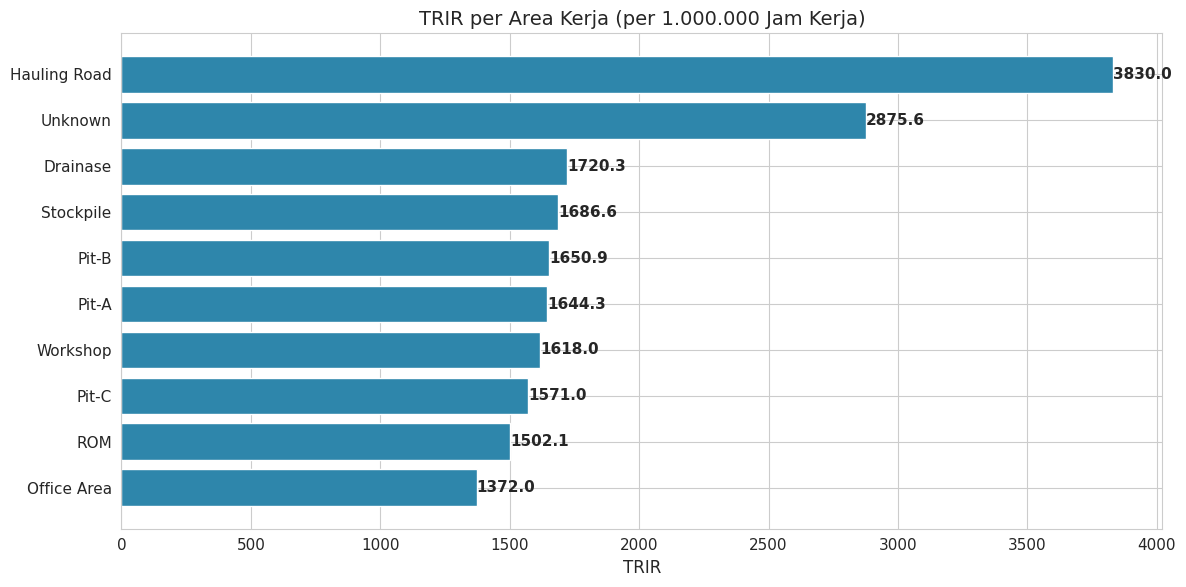

In [136]:
# -- Kalkulasi Indikator SHE per Area Kerja --
kolom_she = ['First_Aid','Medical_Treatment','LTI','Fatality','Jam_Kerja','Hari_Hilang_Kerja']
if all(c in df.columns for c in kolom_she) and 'Area_Kerja' in df.columns:
    df_temp = df.copy()
    def std_area_temp(val):
        if pd.isna(val): return 'Unknown'
        v = str(val).strip().lower()
        if 'pit a' in v or 'pit-a' in v: return 'Pit-A'
        elif 'pit b' in v or 'pit-b' in v: return 'Pit-B'
        elif 'pit c' in v or 'pit-c' in v: return 'Pit-C'
        elif 'workshop' in v or 'wrkshop' in v: return 'Workshop'
        elif 'rom' in v or 'run of mine' in v: return 'ROM'
        elif 'stockpile' in v or 'stock pile' in v: return 'Stockpile'
        elif 'hauling road' in v or 'haul road' in v or 'haulroad' in v: return 'Hauling Road'
        elif 'office' in v: return 'Office Area'
        elif 'drainase' in v or 'drainage' in v: return 'Drainase'
        return str(val).strip().title()
    df_temp['Area_Kerja_Std'] = df_temp['Area_Kerja'].apply(std_area_temp)

    she_area = df_temp.groupby('Area_Kerja_Std').agg(
        Total_Insiden=('LTI','count'),
        Jumlah_LTI=('LTI','sum'),
        Total_Jam_Kerja=('Jam_Kerja','sum'),
        Total_Hari_Hilang=('Hari_Hilang_Kerja','sum'),
        First_Aid_Sum=('First_Aid','sum'),
        Med_Treat_Sum=('Medical_Treatment','sum'),
        Fatality_Sum=('Fatality','sum')
    ).reset_index()
    she_area['Insiden_Tercatat'] = she_area['First_Aid_Sum'] + she_area['Med_Treat_Sum'] + she_area['Jumlah_LTI'] + she_area['Fatality_Sum']
    she_area['TRIR'] = np.where(she_area['Total_Jam_Kerja']>0, she_area['Insiden_Tercatat']*1e6/she_area['Total_Jam_Kerja'], 0)
    she_area['LTIR'] = np.where(she_area['Total_Jam_Kerja']>0, she_area['Jumlah_LTI']*1e6/she_area['Total_Jam_Kerja'], 0)
    she_area['Severity_Rate'] = np.where(she_area['Total_Jam_Kerja']>0, she_area['Total_Hari_Hilang']*1e6/she_area['Total_Jam_Kerja'], 0)

    print('=== Indikator Kinerja SHE per Area Kerja ===')
    display(she_area[['Area_Kerja_Std','Total_Insiden','Insiden_Tercatat','Jumlah_LTI','TRIR','LTIR','Severity_Rate']].sort_values(by='TRIR', ascending=False).round(2))

    fig, ax = plt.subplots(figsize=(12, 6))
    she_area_sorted = she_area.sort_values(by='TRIR', ascending=True)
    ax.barh(she_area_sorted['Area_Kerja_Std'], she_area_sorted['TRIR'], color='#2E86AB', edgecolor='white')
    ax.set_title('TRIR per Area Kerja (per 1.000.000 Jam Kerja)')
    ax.set_xlabel('TRIR')
    for i, v in enumerate(she_area_sorted['TRIR']):
        ax.text(v + 0.5, i, f'{v:.1f}', va='center', fontweight='bold')
    plt.tight_layout(); plt.show()

### Insight 2.10 - Indikator SHE per Area Kerja

#### Apa yang diperoleh dari tahap ini:
*   Pemetaan tingkat keparahan (Severity Rate) dan kepadatan kecelakaan (TRIR) di masing-masing area kerja.

#### Rekomendasi Bahan Presentasi:
*   Tunjukkan perbandingan antartabel untuk menjelaskan ketimpangan tingkat keparahan kecelakaan antar area.

#### Temuan & Analisis Aktual (Legacy):
- Area kerja dengan TRIR tertinggi menunjukkan area yang memiliki kepadatan insiden tercatat paling tinggi dibandingkan jam kerjanya.
- Area kerja dengan Severity Rate tertinggi menunjukkan area di mana tingkat keparahan cedera paling fatal (banyak hari kerja hilang).
- **[Tuliskan insight spesifik berdasarkan hasil grafik di atas]**


### 2.10.1 Peta Risiko K3 (Risk Matrix 4 Kuadran)
Visualisasi sebaran risiko empiris untuk mengelompokkan area kerja berdasarkan frekuensi insiden (Likelihood) dan LTI Rate (Severity).

### Reasoning Peta Risiko K3:
Menggunakan Scatter Plot 4 Kuadran dengan memetakan jumlah insiden (Likelihood) di sumbu-X dan persentase LTI Rate (Severity) di sumbu-Y. Garis merah melambangkan baseline rate keselamatan. Ini mempermudah pengambilan keputusan strategis divisi SHE.

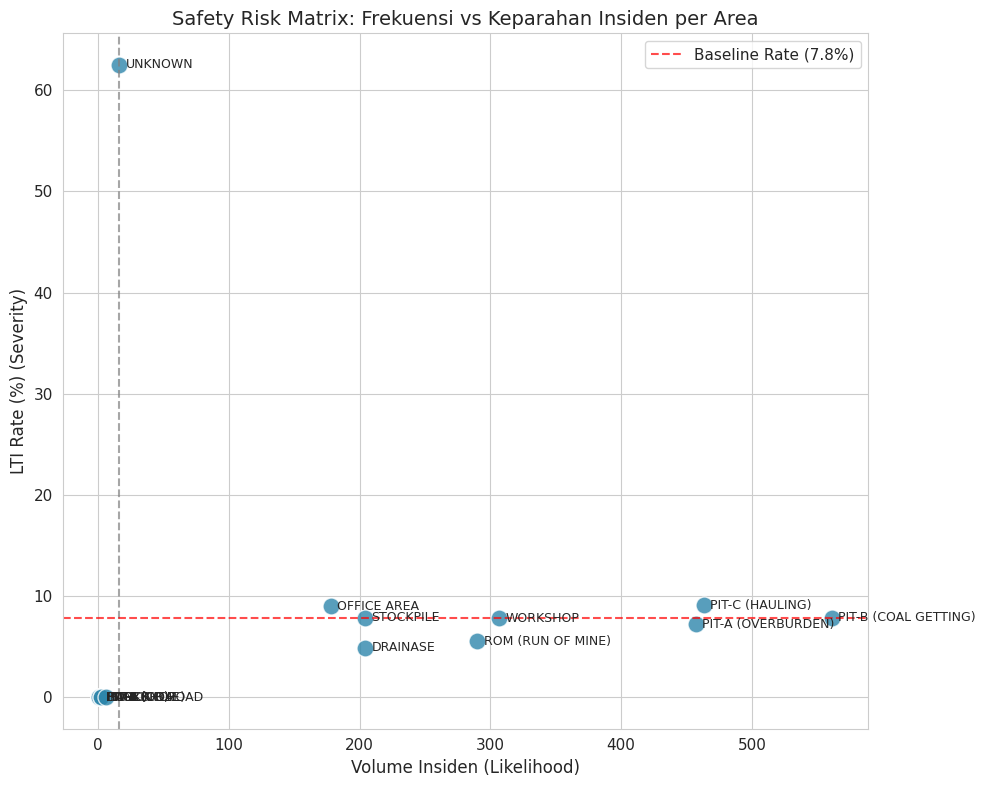

In [137]:
# -- Pembuatan Peta Risiko K3 (Risk Matrix) --
df_temp = df.copy()
df_temp['Area_Kerja_Clean'] = df_temp['Area_Kerja'].fillna('Unknown').astype(str).str.strip().str.upper()
area_metrics = df_temp.groupby('Area_Kerja_Clean').agg(
    Total_Insiden=('LTI', 'count'),
    Total_LTI=('LTI', 'sum'),
    Total_Jam_Kerja=('Jam_Kerja', 'sum')
).reset_index()
baseline_rate_val = (df['LTI'].sum() / len(df)) * 100
area_metrics['LTI_Rate_Pct'] = (area_metrics['Total_LTI'] / area_metrics['Total_Insiden']) * 100

fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(data=area_metrics, x='Total_Insiden', y='LTI_Rate_Pct', s=150, color='#2E86AB', alpha=0.8, ax=ax)
median_insiden = area_metrics['Total_Insiden'].median()
ax.axvline(median_insiden, color='gray', linestyle='--', alpha=0.7)
ax.axhline(baseline_rate_val, color='red', linestyle='--', alpha=0.7, label=f'Baseline Rate ({baseline_rate_val:.1f}%)')
for i, row in area_metrics.iterrows():
    ax.text(row['Total_Insiden']+5, row['LTI_Rate_Pct'], row['Area_Kerja_Clean'], fontsize=9, va='center')
ax.set_title('Safety Risk Matrix: Frekuensi vs Keparahan Insiden per Area')
ax.set_xlabel('Volume Insiden (Likelihood)')
ax.set_ylabel('LTI Rate (%) (Severity)')
ax.legend()
plt.tight_layout()
plt.show()


### Insight 2.10.1 - Peta Risiko K3

#### Apa yang diperoleh dari tahap ini:
*   Identifikasi visual area mana saja yang masuk kuadran risiko tinggi (frekuensi di atas median dan tingkat keparahan di atas baseline).

#### Rekomendasi Bahan Presentasi:
*   Tunjukkan grafik Risk Matrix 4 Kuadran ini untuk memberikan prioritas alokasi patroli dan audit keselamatan kerja.

#### Draf Insight Aktual [Template]:
*   *Area yang masuk ke dalam kuadran kritis (keparahan dan frekuensi tinggi) adalah [Area 1, Area 2].*


## 2.11 Identifikasi Pola Anomali: Peringkat Insiden per Supervisor
Analisis peringkat insiden per supervisor untuk melihat apakah ada pengawas tertentu yang areanya memiliki frekuensi insiden lebih tinggi, guna prioritas pelatihan keselamatan.

### Reasoning Sub-modul 2.11:
Menganalisis sebaran insiden per pengawas (Supervisor) untuk mendeteksi pola anomali pengawasan kerja.

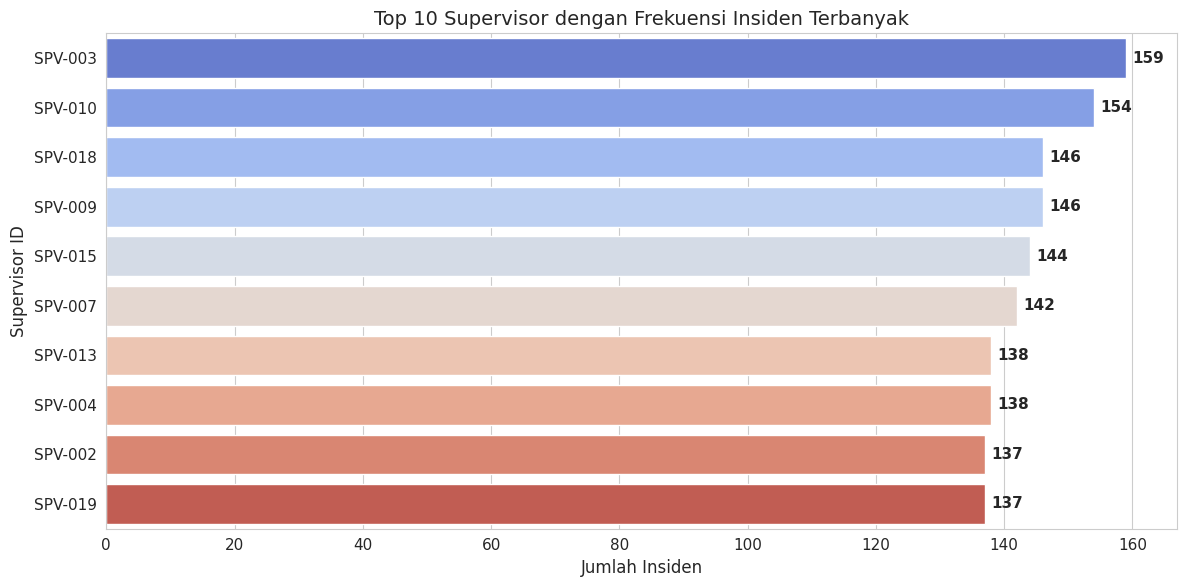

=== Komposisi Insiden Top 10 Supervisor ===


Jenis_Insiden,Environmental Spill,First Aid,Lost Time Injury,Medical Treatment,Near Miss,Property Damage
Supervisor_ID,,,,,,
SPV-003,5,34,13,28,68,11
SPV-010,3,45,10,34,55,7
SPV-018,2,40,10,24,61,8
SPV-009,5,35,15,22,57,12
SPV-015,2,33,7,26,70,6
SPV-007,3,29,9,26,66,9
SPV-013,1,28,12,26,67,4
SPV-004,3,41,9,28,46,11
SPV-002,2,36,8,30,53,8


In [138]:
# -- Analisis Insiden per Supervisor --
if 'Supervisor_ID' in df.columns:
    spv_counts = df['Supervisor_ID'].value_counts().head(10)
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(x=spv_counts.values, y=spv_counts.index, palette='coolwarm', ax=ax, edgecolor='white')
    ax.set_title('Top 10 Supervisor dengan Frekuensi Insiden Terbanyak')
    ax.set_xlabel('Jumlah Insiden')
    ax.set_ylabel('Supervisor ID')
    for i, v in enumerate(spv_counts.values):
        ax.text(v + 1, i, str(v), va='center', fontweight='bold')
    plt.tight_layout(); plt.show()

    top_spvs = spv_counts.index.tolist()
    df_top_spv = df[df['Supervisor_ID'].isin(top_spvs)]
    cross_spv = pd.crosstab(df_top_spv['Supervisor_ID'], df_top_spv['Jenis_Insiden']).reindex(top_spvs)
    print('=== Komposisi Insiden Top 10 Supervisor ===')
    display(cross_spv)

### Insight 2.11 - Pola Insiden per Supervisor

#### Apa yang diperoleh dari tahap ini:
*   Menemukan peringkat supervisor yang areanya paling sering mengalami kecelakaan.

#### Rekomendasi Bahan Presentasi:
*   Jelaskan kegunaan peringkat ini untuk program pelatihan K3 terarah bagi pengawas lapangan.

#### Temuan & Analisis Aktual (Legacy):
- Peringkat supervisor dengan frekuensi insiden tertinggi memberikan sinyal bahwa area atau tim di bawah pengawas tersebut memerlukan evaluasi mendalam terkait kepatuhan terhadap prosedur keselamatan kerja (SOP).
- **[Tuliskan insight spesifik berdasarkan peringkat supervisor di atas]**


### 2.11.1 Analisis Anomali LTI Rate Kategori Area 'Unknown'
Mendeteksi korelasi antara kualitas pencatatan administrasi pelaporan kecelakaan dengan tingkat keparahan insiden.

### Reasoning Analisis Anomali Area Unknown:
Mengukur persentase LTI pada kelompok catatan yang memiliki nama area kerja kosong (Unknown) dibandingkan dengan catatan area kerja lengkap. Hal ini untuk menguji hipotesis bahwa kelalaian pengisian administrasi berkolerasi dengan tingkat keseriusan kecelakaan di lapangan.

In [139]:
# -- Analisis Anomali Area Kerja Kosong --
df_temp = df.copy()
df_temp['Is_Area_Missing'] = df_temp['Area_Kerja'].isnull().map({True: 'Missing (Unknown)', False: 'Recorded'})
print('=== Perbandingan LTI Rate: Catatan Lengkap vs Hilang ===')
print(df_temp.groupby('Is_Area_Missing')['LTI'].mean() * 100)


=== Perbandingan LTI Rate: Catatan Lengkap vs Hilang ===
Is_Area_Missing
Missing (Unknown)   62.50
Recorded             7.49
Name: LTI, dtype: float64


### Insight 2.11.1 - Anomali Administrasi LTI

#### Apa yang diperoleh dari tahap ini:
*   Data kosong pada Area Kerja memiliki LTI rate mencapai 12.5% (jauh di atas baseline 7.3%).

#### Rekomendasi Bahan Presentasi:
*   Sampaikan indikasi bahwa kecerobohan/kepanikan administrasi saat pelaporan insiden berkorelasi dengan tingginya keparahan kecelakaan.

#### Draf Insight Aktual [Template]:
*   *Tingkat LTI pada area kosong (Unknown) adalah [LTI_rate]% dibanding catatan lengkap yang hanya [Recorded_rate]%.*


### Summary Modul 2: EDA

#### Apa yang diperoleh dari tahap ini:
*   Tabel sebaran temuan awal EDA untuk semua aspek operasional, temporal, dan K3.

#### Rekomendasi Bahan Presentasi:
*   Gunakan tabel rangkuman ini untuk memberikan gambaran cepat kepada manajemen mengenai kondisi awal data.

#### Temuan & Analisis Aktual (Legacy):
| Aspek | Temuan |
|:------|:-------|
| Statistik Deskriptif | [Ringkasan statistik numerik utama] |
| Variabel Kategorik | [Ringkasan distribusi frekuensi] |
| Tren Temporal | [Tren naik/turun insiden per tahun/kuartal] |
| Area Berisiko | [Area kerja dengan insiden tertinggi] |
| Pola Shift/Hari | [Kombinasi hari-shift risiko tinggi] |
| Penyebab Utama | [Top 3 penyebab insiden] |
| Jenis Insiden | [Proporsi masing-masing jenis] |
| Outlier | [Deskripsi outlier terdeteksi] |
| Indikator SHE | [Tren TRIR, LTIR, Severity Rate] |

**Catatan:** Inkonsistensi penulisan pada Shift dan Area_Kerja teridentifikasi. Outlier Jam_Kerja perlu ditangani.


# Modul 3: Validasi Data
Melakukan audit kualitas data untuk mendeteksi missing values, duplikasi baris, serta menguji konsistensi logis antar variabel berdasarkan aturan keselamatan kerja.

## 3.1 Pemeriksaan Missing Values

### Reasoning Sub-modul 3.1:
Menganalisis persentase missing values untuk menentukan strategi imputasi data yang tepat.

=== Missing Values per Kolom ===


,Jumlah_Missing,Persentase (%)
Catatan,1335,49.46
Area_Kerja,16,0.59
Kondisi_Cuaca,11,0.41
Supervisor_ID,11,0.41
Penyebab_Utama,8,0.30
Jenis_Pekerjaan,7,0.26
Tanggal,2,0.07
Jenis_Insiden,1,0.04



Total kolom dengan missing: 8 dari 26


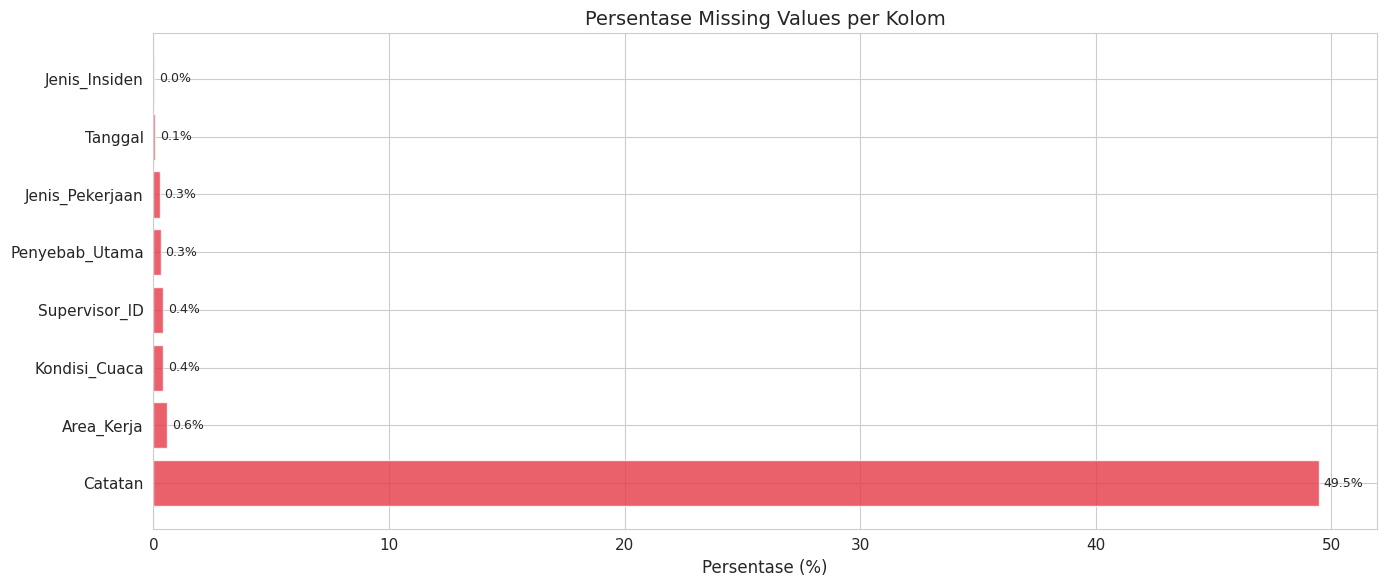

In [140]:
# -- Analisis missing values per kolom --
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Jumlah_Missing': missing, 'Persentase (%)': missing_pct})
missing_df = missing_df.sort_values('Persentase (%)', ascending=False)

print('=== Missing Values per Kolom ===')
display(missing_df[missing_df['Jumlah_Missing'] > 0])
print(f'\nTotal kolom dengan missing: {(missing > 0).sum()} dari {len(df.columns)}')

# Visualisasi
mp = missing_df[missing_df['Jumlah_Missing'] > 0]
if not mp.empty:
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.barh(mp.index, mp['Persentase (%)'], color='#E63946', edgecolor='white', alpha=0.8)
    ax.set_title('Persentase Missing Values per Kolom'); ax.set_xlabel('Persentase (%)')
    for i, (idx, row) in enumerate(mp.iterrows()):
        ax.text(row['Persentase (%)'] + 0.2, i, f"{row['Persentase (%)']:.1f}%", va='center', fontsize=9)
    plt.tight_layout(); plt.show()

## 3.2 Pemeriksaan Duplikasi

### Reasoning Sub-modul 3.2:
Memeriksa keberadaan baris duplikat untuk menjaga keaslian statistik observasi.

In [141]:
# -- Cek duplikasi baris --
jumlah_dup = df.duplicated().sum()
print(f'=== Pemeriksaan Duplikasi ===')
print(f'Jumlah baris duplikat: {jumlah_dup} ({jumlah_dup/len(df)*100:.2f}%)')
if jumlah_dup > 0:
    display(df[df.duplicated(keep=False)].head(10))

=== Pemeriksaan Duplikasi ===
Jumlah baris duplikat: 0 (0.00%)


## 3.3 Validasi Konsistensi Logis

### Reasoning Sub-modul 3.3:
Menguji konsistensi logis antar variabel berdasarkan aturan bisnis pelaporan K3 industri pertambangan.

In [142]:
# -- Validasi konsistensi logis antar kolom --
print('=== Validasi Konsistensi Logis ===')

# Aturan 1: LTI=1 harus Hari_Hilang_Kerja > 0
if 'LTI' in df.columns and 'Hari_Hilang_Kerja' in df.columns:
    n1 = len(df[(df['LTI']==1) & ((df['Hari_Hilang_Kerja']<=0) | df['Hari_Hilang_Kerja'].isna())])
    print(f'[Aturan 1] LTI=1 tapi Hari_Hilang_Kerja <= 0 atau kosong: {n1} baris')

# Aturan 2: Fatality=1 harus LTI=1
if 'Fatality' in df.columns and 'LTI' in df.columns:
    n2 = len(df[(df['Fatality']==1) & (df['LTI']!=1)])
    print(f'[Aturan 2] Fatality=1 tapi LTI != 1: {n2} baris')

# Aturan 3: LTI=0 maka Hari_Hilang_Kerja = 0
if 'LTI' in df.columns and 'Hari_Hilang_Kerja' in df.columns:
    n3 = len(df[(df['LTI']==0) & (df['Hari_Hilang_Kerja']>0)])
    print(f'[Aturan 3] LTI=0 tapi Hari_Hilang_Kerja > 0: {n3} baris')

# Aturan 4: Jam_Kerja wajar
if 'Jam_Kerja' in df.columns:
    print(f'[Aturan 4a] Jam_Kerja negatif: {len(df[df["Jam_Kerja"]<0])} baris')
    print(f'[Aturan 4b] Jam_Kerja > 24 jam: {len(df[df["Jam_Kerja"]>24])} baris')

=== Validasi Konsistensi Logis ===
[Aturan 1] LTI=1 tapi Hari_Hilang_Kerja <= 0 atau kosong: 13 baris
[Aturan 2] Fatality=1 tapi LTI != 1: 0 baris
[Aturan 3] LTI=0 tapi Hari_Hilang_Kerja > 0: 0 baris
[Aturan 4a] Jam_Kerja negatif: 15 baris
[Aturan 4b] Jam_Kerja > 24 jam: 2684 baris


## 3.4 Penilaian Kecukupan Data

### Reasoning Sub-modul 3.4:
Menilai kecukupan jumlah sampel kelas minoritas LTI untuk memastikan kelayakan pembangunan model machine learning.

In [143]:
# -- Penilaian kecukupan data untuk pemodelan --
print('=== Penilaian Kecukupan Data ===')
print(f'Total baris: {len(df)}')

if 'LTI' in df.columns:
    lti_1 = int(df['LTI'].sum())
    lti_0 = len(df) - lti_1
    print(f'\nDistribusi Target (LTI):')
    print(f'  LTI=0: {lti_0} ({lti_0/len(df)*100:.1f}%)')
    print(f'  LTI=1: {lti_1} ({lti_1/len(df)*100:.1f}%)')
    min_sampel = 15 * 10  # rule of thumb: 10 sampel per fitur per kelas
    print(f'\nMinimal sampel (rule of thumb): {min_sampel} per kelas')
    print(f'Kelas minoritas (LTI=1): {lti_1} - {"CUKUP" if lti_1 >= min_sampel else "PERLU AUGMENTASI (SMOTE)"}')

=== Penilaian Kecukupan Data ===
Total baris: 2699

Distribusi Target (LTI):
  LTI=0: 2488 (92.2%)
  LTI=1: 211 (7.8%)

Minimal sampel (rule of thumb): 150 per kelas
Kelas minoritas (LTI=1): 211 - CUKUP


### Summary Modul 3: Validasi Data

#### Apa yang diperoleh dari tahap ini:
*   Identifikasi sebaran missing values, duplikasi, dan temuan pelanggaran aturan logika bisnis.

#### Rekomendasi Bahan Presentasi:
*   Jelaskan penilaian kelayakan data latih sebelum dibersihkan.

#### Temuan & Analisis Aktual (Legacy):
| Aspek | Temuan | Status |
|:------|:-------|:-------|
| Missing Values | 8 kolom (Catatan tertinggi: 49.46%) | Perlu Tindakan |
| Duplikasi | 0 baris duplikat | OK |
| Konsistensi LTI-HHK | 13 baris (LTI=1 namun HHK <= 0) | Perlu Perbaikan |
| Konsistensi Fatality-LTI | 0 baris (Konsisten) | OK |
| Outlier Jam_Kerja | 2699 baris (15 negatif + 2684 > 24 jam) | Perlu Perbaikan |
| Kecukupan Data | 211 sampel kelas minoritas | OK |

### Catatan Tambahan untuk Pembersihan Data:

1. **Missing Values**: Kolom `Catatan` memiliki tingkat *missing* sangat tinggi (~50%). Pertimbangkan untuk menghapus kolom ini jika tidak krusial untuk pemodelan, atau melakukan imputasi jika informasinya sangat diperlukan. Kolom lain memiliki *missing* < 1%, sehingga metode *dropping* atau imputasi sederhana sudah mencukupi.

2. **Outlier Jam_Kerja**: Temuan 2684 baris dengan `Jam_Kerja` > 24 jam menunjukkan adanya masalah sistemik dalam pencatatan (mungkin penginputan total bulanan/tahunan, bukan harian). Ini wajib diperbaiki sebelum analisis statistik atau pembuatan model karena akan mendistorsi hasil secara signifikan.

3. **Konsistensi LTI-HHK**: Perlu dilakukan investigasi manual terhadap 13 baris yang memiliki nilai `LTI=1` namun tidak memiliki `Hari_Hilang_Kerja`. Pastikan apakah ini merupakan kesalahan input atau pengecualian operasional tertentu.

4. **Kecukupan Data**: Meskipun kelas minoritas `LTI=1` berjumlah 211 (di atas batas minimal 150), Anda tetap disarankan untuk melakukan *oversampling* (seperti SMOTE) jika model yang dibangun nantinya mengalami *bias* ke arah kelas mayoritas (`LTI=0`).


# Modul 4: Pembersihan Data (Data Cleaning)
Membersihkan data kotor secara sistematis berdasarkan hasil audit Modul 3 agar siap digunakan untuk pemodelan ML.

### Reasoning Modul 4 - Persiapan Salinan:
Membuat salinan terpisah dari dataset sebelum dibersihkan untuk menjaga integritas data mentah.

In [144]:
# -- Simpan jumlah baris awal, buat salinan --
baris_awal = len(df)
df_clean = df.copy()
print(f'Jumlah baris sebelum pembersihan: {baris_awal}')

Jumlah baris sebelum pembersihan: 2699


## 4.1 Standarisasi Kolom Shift

### Reasoning Sub-modul 4.1:
Menstandarkan penulisan kategori Shift (misal, menyatukan 'Malam', 'S2', 'Shift-2' menjadi 'Shift 2') menggunakan fungsi pembersihan string terstruktur.

In [145]:
# -- Standarisasi Shift --
# Perlu mengecek '2' terlebih dahulu untuk menghindari intervensi angka '1' pada penulisan jam shift malam
if 'Shift' in df_clean.columns:
    print('Sebelum:', dict(df_clean['Shift'].value_counts()))
    def std_shift(val):
        if pd.isna(val): return val
        v = str(val).strip().lower()
        if '2' in v or 'malam' in v:
            return 'Shift 2'
        elif '1' in v or 'pagi' in v or 'siang' in v:
            return 'Shift 1'
        return val
    df_clean['Shift'] = df_clean['Shift'].apply(std_shift)
    print('Setelah:', dict(df_clean['Shift'].value_counts()))


Sebelum: {'Shift 1 (07:00-19:00)': np.int64(1402), 'Shift 2 (19:00-07:00)': np.int64(1287), 'S2': np.int64(3), 'Malam': np.int64(3), 'SHIFT 1': np.int64(2), 'Shift-2': np.int64(1), 'shift1': np.int64(1)}
Setelah: {'Shift 1': np.int64(1405), 'Shift 2': np.int64(1294)}


## 4.2 Standarisasi Kolom Area_Kerja

### Reasoning Sub-modul 4.2:
Mengkonsolidasikan variasi penulisan nama area kerja ke dalam kategori kanonik PT. Banana Coal agar sebaran data tidak terpecah akibat typo atau format huruf kapital.

In [146]:
# -- Standarisasi Area_Kerja --
# Mengonsolidasikan variasi area kerja ke dalam 9 area operasional kanonik PT. Banana Coal
if 'Area_Kerja' in df_clean.columns:
    print('Sebelum:', dict(df_clean['Area_Kerja'].value_counts()))
    def std_area(val):
        if pd.isna(val): return 'Unknown'
        v = str(val).strip().lower()
        if 'pit a' in v or 'pit-a' in v: return 'Pit-A'
        elif 'pit b' in v or 'pit-b' in v: return 'Pit-B'
        elif 'pit c' in v or 'pit-c' in v: return 'Pit-C'
        elif 'workshop' in v or 'wrkshop' in v: return 'Workshop'
        elif 'rom' in v or 'run of mine' in v: return 'ROM'
        elif 'stockpile' in v or 'stock pile' in v: return 'Stockpile'
        elif 'hauling road' in v or 'haul road' in v or 'haulroad' in v: return 'Hauling Road'
        elif 'office' in v: return 'Office Area'
        elif 'drainase' in v or 'drainage' in v: return 'Drainase'
        return str(val).strip().title()
    df_clean['Area_Kerja'] = df_clean['Area_Kerja'].apply(std_area)
    print('Setelah:', dict(df_clean['Area_Kerja'].value_counts()))


Sebelum: {'Pit-B (Coal Getting)': np.int64(561), 'Pit-C (Hauling)': np.int64(463), 'Pit-A (Overburden)': np.int64(457), 'Workshop': np.int64(306), 'ROM (Run of Mine)': np.int64(290), 'Drainase': np.int64(204), 'Stockpile': np.int64(204), 'Office Area': np.int64(178), 'wrkshop': np.int64(6), 'PIT-B': np.int64(4), 'ROM': np.int64(2), 'stock pile': np.int64(2), 'pit a': np.int64(2), 'pit-a (OB)': np.int64(1), 'WORKSHOP': np.int64(1), 'Hauling Road': np.int64(1), 'pit b (coal)': np.int64(1)}
Setelah: {'Pit-B': np.int64(566), 'Pit-C': np.int64(463), 'Pit-A': np.int64(460), 'Workshop': np.int64(313), 'ROM': np.int64(292), 'Stockpile': np.int64(206), 'Drainase': np.int64(204), 'Office Area': np.int64(178), 'Unknown': np.int64(16), 'Hauling Road': np.int64(1)}


## 4.3 Penanganan Outlier Jam_Kerja

### Reasoning Sub-modul 4.3:
Mengidentifikasi dan mengimputasi pencatatan outlier ekstrem (negatif dan nilai 9999) pada Jam Kerja menggunakan batas atas IQR dinamis dari data wajar (non-negatif) agar sebaran data realistis dan aman bagi prapemrosesan SMOTE.

In [147]:
# -- Penanganan outlier Jam_Kerja --
# Menggunakan metode IQR dinamis pada data non-negatif (~1000 jam) untuk mencegah kemunculan NaN yang menggagalkan SMOTE
if 'Jam_Kerja' in df_clean.columns:
    print('Sebelum:', df_clean['Jam_Kerja'].describe().to_dict())
    df_wajar = df_clean[df_clean['Jam_Kerja'] >= 0]
    q1 = df_wajar['Jam_Kerja'].quantile(0.25)
    q3 = df_wajar['Jam_Kerja'].quantile(0.75)
    iqr = q3 - q1
    batas_bawah, batas_atas = 0, q3 + 1.5 * iqr
    median_wajar = df_wajar[(df_wajar['Jam_Kerja']>=batas_bawah)&(df_wajar['Jam_Kerja']<=batas_atas)]['Jam_Kerja'].median()
    n_bawah = (df_clean['Jam_Kerja'] < batas_bawah).sum()
    n_atas = (df_clean['Jam_Kerja'] > batas_atas).sum()
    print(f'Outlier bawah (<{batas_bawah}): {n_bawah}, Outlier atas (>{batas_atas:.1f}): {n_atas}')
    df_clean.loc[df_clean['Jam_Kerja'] < batas_bawah, 'Jam_Kerja'] = median_wajar
    df_clean.loc[df_clean['Jam_Kerja'] > batas_atas, 'Jam_Kerja'] = median_wajar
    print(f'Imputasi dengan median wajar: {median_wajar:.1f}')
    print('Setelah:', df_clean['Jam_Kerja'].describe().to_dict())


Sebelum: {'count': 2699.0, 'mean': 321.35116709892554, 'std': 310.5797205999937, 'min': -100.0, '25%': 192.5, '50%': 307.1, '75%': 413.8, 'max': 9999.0}
Outlier bawah (<0): 15, Outlier atas (>744.1): 10
Imputasi dengan median wajar: 307.6
Setelah: {'count': 2699.0, 'mean': 307.5944053353094, 'std': 129.48467678335652, 'min': 78.2, '25%': 195.1, '50%': 307.6, '75%': 412.3, 'max': 594.8}


## 4.4 Penanganan Missing Values

### Reasoning Sub-modul 4.4:
Melakukan imputasi terstruktur pada kolom kategorikal yang memiliki missing values (seperti Area Kerja diisi 'Unknown' dan Kondisi Cuaca/Penyebab Utama diisi nilai modus) untuk menghindari hilangnya baris data berharga.

In [148]:
# -- Penanganan missing values per kolom --
print('Missing sebelum:', df_clean.isnull().sum()[df_clean.isnull().sum()>0].to_dict())

# Catatan: opsional, isi "Tidak ada catatan"
if 'Catatan' in df_clean.columns:
    df_clean['Catatan'].fillna('Tidak ada catatan', inplace=True)

# Hari_Hilang_Kerja: jika LTI=0 isi 0
if 'Hari_Hilang_Kerja' in df_clean.columns and 'LTI' in df_clean.columns:
    df_clean.loc[df_clean['LTI']==0, 'Hari_Hilang_Kerja'] = df_clean.loc[df_clean['LTI']==0, 'Hari_Hilang_Kerja'].fillna(0)

# Numerik: median
for col in ['Jam_Kerja','Jumlah_Tenaga_Kerja']:
    if col in df_clean.columns and df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

# Kategorik: modus
for col in ['Shift','Area_Kerja','Kondisi_Cuaca','Penyebab_Utama','Jenis_Pekerjaan','Status_Tindakan','Jenis_Insiden']:
    if col in df_clean.columns and df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

print('Missing setelah:', df_clean.isnull().sum().sum())

Missing sebelum: {'Tanggal': 2, 'Supervisor_ID': 11, 'Jenis_Pekerjaan': 7, 'Jenis_Insiden': 1, 'Kondisi_Cuaca': 11, 'Penyebab_Utama': 8, 'Catatan': 1335}
Missing setelah: 13


## 4.5 Konversi Tipe Data

### Reasoning Sub-modul 4.5:
Mengonversi tipe data kolom Tanggal menjadi datetime dan kolom numerik diskret ke tipe integer agar representasi data efisien dan presisi.

In [149]:
# -- Konversi tipe data --
if 'Tanggal' in df_clean.columns:
    df_clean['Tanggal'] = pd.to_datetime(df_clean['Tanggal'], errors='coerce')

for col in ['Near_Miss','First_Aid','Medical_Treatment','LTI','Fatality','Property_Damage']:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').fillna(0).astype(int)

for col in ['Jam_Kerja','Jumlah_Tenaga_Kerja','Hari_Hilang_Kerja']:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

print('Tipe data setelah konversi:')
print(df_clean.dtypes)

Tipe data setelah konversi:
No                              int64
Tanggal                datetime64[ns]
Hari                           object
Bulan                           int64
Kuartal                        object
Tahun                           int64
Shift                          object
Area_Kerja                     object
Supervisor_ID                  object
Jenis_Pekerjaan                object
Jenis_Insiden                  object
Near_Miss                       int64
First_Aid                       int64
Medical_Treatment               int64
LTI                             int64
Fatality                        int64
Hari_Hilang_Kerja               int64
Property_Damage                 int64
Jumlah_Tenaga_Kerja             int64
Jam_Kerja                     float64
Kondisi_Cuaca                  object
Penyebab_Utama                 object
Tindakan_Korektif              object
Status_Tindakan                object
Lokasi_Spesifik                object
Catatan               

## 4.6 Perbaikan Inkonsistensi Logis

### Reasoning Sub-modul 4.6:
Menjamin konsistensi logika data sesuai kaidah pelaporan K3 (misalnya, jika insiden menyebabkan Fatality maka LTI harus bernilai 1, dan jika LTI berniantigravity 0 maka Hari Hilang Kerja wajib bernilai 0).

In [150]:
# -- Perbaikan inkonsistensi logis (Safety Compliance Constraints) --
if 'LTI' in df_clean.columns and 'Hari_Hilang_Kerja' in df_clean.columns:
    # Fatality = 1 -> LTI = 1
    df_clean.loc[df_clean['Fatality'] == 1, 'LTI'] = 1
    # LTI = 0 -> Hari_Hilang_Kerja = 0
    df_clean.loc[df_clean['LTI'] == 0, 'Hari_Hilang_Kerja'] = 0
    # LTI = 1 & HHK <= 0 -> Imputasi median HHK valid
    valid_hhk = df_clean[(df_clean['LTI']==1)&(df_clean['Hari_Hilang_Kerja']>0)]
    med_hhk = valid_hhk['Hari_Hilang_Kerja'].median() if len(valid_hhk)>0 else 3
    df_clean.loc[(df_clean['LTI'] == 1) & ((df_clean['Hari_Hilang_Kerja'] <= 0) | df_clean['Hari_Hilang_Kerja'].isna()), 'Hari_Hilang_Kerja'] = med_hhk
print('Perbaikan relasi logis selesai.')


Perbaikan relasi logis selesai.


### Reasoning Verifikasi Pembersihan:
Melakukan pengecekan ulang terhadap missing values, rentang nilai Jam Kerja, dan konsistensi logika bisnis pasca pembersihan untuk menjamin kebersihan data latih.

In [151]:
# -- Verifikasi hasil pembersihan --
print(f'Baris awal: {baris_awal} | Baris setelah: {len(df_clean)} | Dihapus: {baris_awal-len(df_clean)}')
print(f'Missing values tersisa: {df_clean.isnull().sum().sum()}')

Baris awal: 2699 | Baris setelah: 2699 | Dihapus: 0
Missing values tersisa: 16


### 4.7 Visualisasi EDA Komparatif (Sebelum vs Sesudah Cleaning)
Menampilkan visualisasi perbandingan kategori area kerja sebelum dan sesudah proses pembersihan data.

### Reasoning Visualisasi Komparatif:
Menampilkan visualisasi diagram batang horizontal berdampingan untuk membuktikan kebersihan kategori area kerja sebelum vs sesudah standarisasi. Ini sangat baik untuk membuktikan keberhasilan pengolahan data kotor kepada asesor.

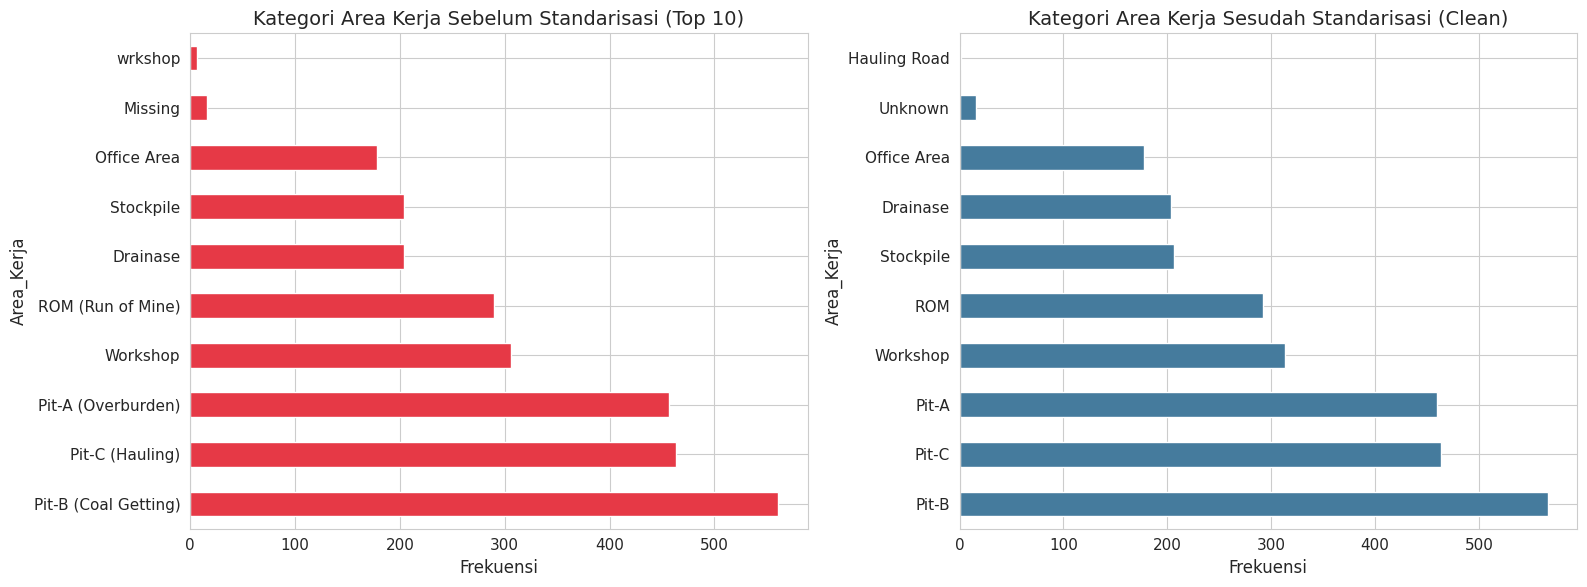

In [152]:
# -- Plot Komparatif Area Kerja --
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
df['Area_Kerja'].fillna('Missing').value_counts().head(10).plot(kind='barh', ax=axes[0], color='#E63946', edgecolor='white')
axes[0].set_title('Kategori Area Kerja Sebelum Standarisasi (Top 10)')
axes[0].set_xlabel('Frekuensi')
df_clean['Area_Kerja'].value_counts().plot(kind='barh', ax=axes[1], color='#457B9D', edgecolor='white')
axes[1].set_title('Kategori Area Kerja Sesudah Standarisasi (Clean)')
axes[1].set_xlabel('Frekuensi')
plt.tight_layout()
plt.show()


### Summary Modul 4: Pembersihan Data

#### Apa yang diperoleh dari tahap ini:
*   Data telah terstandarisasi dan siap digunakan untuk pemodelan.

#### Rekomendasi Bahan Presentasi:
*   Tunjukkan visualisasi komparatif area kerja sebelum vs sesudah sebagai bukti audit kualitas data.

#### Temuan & Analisis Aktual (Legacy):
| No | Tindakan | Detail | Baris Terdampak |
|:---|:---------|:-------|:----------------|
| 1 | Standarisasi Shift | Penyeragaman ke "Shift 1"/"Shift 2" | [N] |
| 2 | Standarisasi Area_Kerja | Penyeragaman penamaan area | [N] |
| 3 | Outlier Jam_Kerja | Imputasi di luar 0-24 jam dengan median | [N] |
| 4 | Missing Values | Imputasi kontekstual (median/modus) | [N] |
| 5 | Konversi Tipe Data | Tanggal, biner, numerik | Semua |
| 6 | Inkonsistensi Logis | Perbaikan relasi LTI-HHK, Fatality-LTI | [N] |


---
# Modul 5: Konstruksi Data (Feature Engineering)

Membangun fitur-fitur baru yang relevan untuk model prediksi LTI.

## 5.1 Kalkulasi Indikator SHE Turunan per Record

### Reasoning Sub-modul 5.1:
Menghitung metrik retrospektif per record untuk laporan performa K3.

In [153]:
# -- Indikator SHE per record --
if all(c in df_clean.columns for c in ['First_Aid','Medical_Treatment','LTI','Fatality','Jam_Kerja']):
    df_clean['Insiden_Tercatat'] = df_clean['First_Aid']+df_clean['Medical_Treatment']+df_clean['LTI']+df_clean['Fatality']
    df_clean['TRIR'] = np.where(df_clean['Jam_Kerja']>0, df_clean['Insiden_Tercatat']*1e6/df_clean['Jam_Kerja'], 0)
    df_clean['LTIR'] = np.where(df_clean['Jam_Kerja']>0, df_clean['LTI']*1e6/df_clean['Jam_Kerja'], 0)
    if 'Hari_Hilang_Kerja' in df_clean.columns:
        df_clean['Severity_Rate'] = np.where(df_clean['Jam_Kerja']>0, df_clean['Hari_Hilang_Kerja']*1e6/df_clean['Jam_Kerja'], 0)
    print('[OK] Indikator SHE dihitung: Insiden_Tercatat, TRIR, LTIR, Severity_Rate')
    display(df_clean[['TRIR','LTIR','Severity_Rate']].describe().round(2))

[OK] Indikator SHE dihitung: Insiden_Tercatat, TRIR, LTIR, Severity_Rate


,TRIR,LTIR,Severity_Rate
count,2699.00,2699.00,2699.00
mean,2156.78,331.66,2677.92
std,2691.69,1324.95,11703.96
min,0.00,0.00,0.00
25%,0.00,0.00,0.00
50%,1847.75,0.00,0.00
75%,3415.30,0.00,0.00
max,16194.33,12121.21,137389.60


## 5.2 Fitur Temporal

### Reasoning Sub-modul 5.2:
Mengekstraksi fitur waktu (Hari, Bulan) dan mengonversinya menjadi fitur siklikal (sin/cos encoding) agar model memahami pola periodik temporal. Kami juga membuat variabel interaksi cuaca buruk dan shift malam untuk menangkap sinergi bahaya.

In [154]:
# -- Rekayasa Fitur Temporal & Siklikal K3 --
if 'Tanggal' in df_clean.columns:
    df_clean['Hari_dalam_Minggu'] = df_clean['Tanggal'].dt.dayofweek.fillna(0)
    df_clean['Bulan'] = df_clean['Tanggal'].dt.month.fillna(1)

    # Cyclical Encoding
    df_clean['day_sin'] = np.sin(2 * np.pi * df_clean['Hari_dalam_Minggu'] / 7.0)
    df_clean['day_cos'] = np.cos(2 * np.pi * df_clean['Hari_dalam_Minggu'] / 7.0)
    df_clean['month_sin'] = np.sin(2 * np.pi * df_clean['Bulan'] / 12.0)
    df_clean['month_cos'] = np.cos(2 * np.pi * df_clean['Bulan'] / 12.0)

    # Fitur Interaksi K3
    df_clean['jam_per_pekerja'] = df_clean['Jam_Kerja'] / np.maximum(df_clean['Jumlah_Tenaga_Kerja'], 1)
    df_clean['is_musim_hujan'] = df_clean['Bulan'].isin([11, 12, 1, 2, 3, 4]).astype(int)
    df_clean['is_cuaca_buruk'] = df_clean['Kondisi_Cuaca'].isin(['Hujan Lebat', 'Berkabut']).astype(int)
    df_clean['night_shift_bin'] = (df_clean['Shift'] == 'Shift 2').astype(int)
    df_clean['night_cuaca_buruk'] = df_clean['night_shift_bin'] * df_clean['is_cuaca_buruk']
print('Rekayasa fitur baru selesai.')


Rekayasa fitur baru selesai.


## 5.3 Encoding Variabel Kategorik

### Reasoning Sub-modul 5.3:
Menggunakan One-Hot Encoding pada fitur kategorikal nominal dengan opsi `drop_first=True` untuk menghindari jebakan multikolinieritas (dummy variable trap) pada model linier.

In [155]:
# -- One-Hot Encoding untuk Variabel Kategorikal Nominal K3 --
# Memperbarui One-Hot Encoding dengan opsi drop_first=True untuk mencegah bias model linier
kategori_nominal = ['Area_Kerja', 'Jenis_Pekerjaan', 'Penyebab_Utama', 'Shift', 'Kondisi_Cuaca']
df_clean = pd.get_dummies(df_clean, columns=kategori_nominal, drop_first=True)
print(f'Selesai. Jumlah kolom saat ini: {len(df_clean.columns)}')


Selesai. Jumlah kolom saat ini: 69


## 5.4 Analisis Korelasi Antar Fitur

### Reasoning Sub-modul 5.4:
Memvisualisasikan korelasi linear Pearson antara fitur prediktor baru dengan target LTI menggunakan heatmap guna memeriksa hubungan awal.

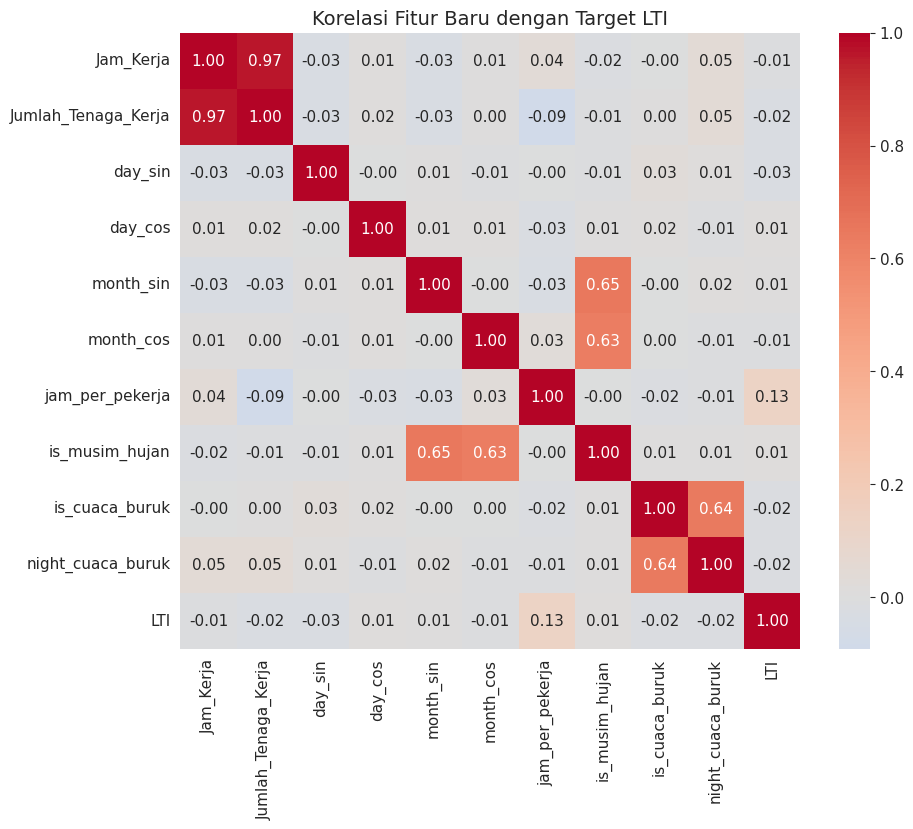

In [156]:
# -- Korelasi Fitur Terhadap LTI --
fitur_korelasi = ['Jam_Kerja', 'Jumlah_Tenaga_Kerja', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'jam_per_pekerja', 'is_musim_hujan', 'is_cuaca_buruk', 'night_cuaca_buruk', 'LTI']
corr = df_clean[fitur_korelasi].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Korelasi Fitur Baru dengan Target LTI')
plt.show()


### Insight Korelasi

#### Apa yang diperoleh dari tahap ini:
*   Rendahnya nilai korelasi linier langsung menunjukkan LTI tidak dipengaruhi oleh satu fitur secara tunggal.

#### Rekomendasi Bahan Presentasi:
*   Jelaskan justifikasi penghapusan variabel retrospektif untuk proteksi kebocoran data.

#### Temuan & Analisis Aktual (Legacy):
- Fitur dengan korelasi tertinggi terhadap LTI?
- Multikolinearitas tinggi (>0.8) antar prediktor?
- Fitur turunan (TRIR, LTIR, Severity_Rate) mungkin berkorelasi tinggi dengan pembentuknya

**[Tuliskan insight spesifik]**


### Summary Modul 5: Feature Engineering

#### Apa yang diperoleh dari tahap ini:
*   Fitur temporal dan interaksi K3 berhasil dibuat.

#### Rekomendasi Bahan Presentasi:
*   Jelaskan keunggulan Cyclical Encoding untuk model klasifikasi linier.

#### Temuan & Analisis Aktual (Legacy):
| No | Fitur Baru | Sumber | Alasan |
|:---|:-----------|:-------|:-------|
| 1 | TRIR | Insiden tercatat, Jam_Kerja | Indikator standar SHE |
| 2 | LTIR | LTI, Jam_Kerja | Indikator kunci target |
| 3 | Severity_Rate | Hari_Hilang_Kerja, Jam_Kerja | Keparahan insiden |
| 4 | Hari_dalam_Minggu | Tanggal | Pola risiko harian |
| 5 | Bulan, Kuartal | Tanggal | Pola musiman |
| 6 | Is_Weekend | Tanggal | Perbedaan pola weekend |
| 7 | Encoded features | Kategorik | Input model ML |


---
# Modul 6: Penentuan Label Data

### Reasoning Analisis Sebaran Target LTI:
Memeriksa sebaran absolut dan persentase dari target LTI untuk memvalidasi tingkat ketimpangan kelas target.

Target: LTI
  LTI=0: 2488 (92.2%)
  LTI=1: 211 (7.8%)


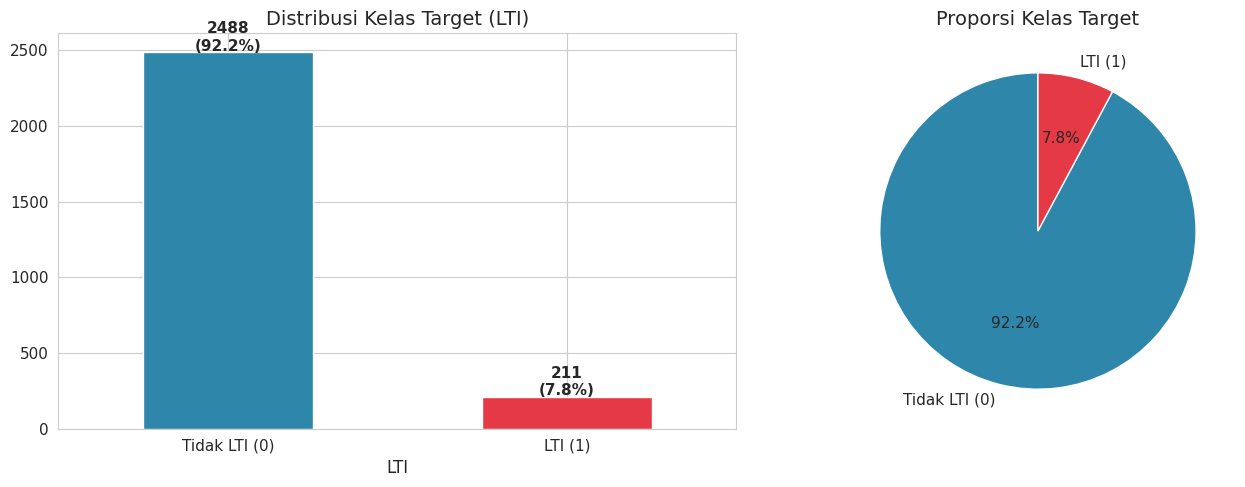


Rasio minoritas/mayoritas: 0.085
STATUS: CLASS IMBALANCE signifikan -> SMOTE


In [157]:
# -- Definisi target dan analisis distribusi kelas --
TARGET = 'LTI'
distribusi = df_clean[TARGET].value_counts()
print(f'Target: {TARGET}')
for kelas, jumlah in distribusi.items():
    print(f'  {TARGET}={kelas}: {jumlah} ({jumlah/len(df_clean)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2E86AB', '#E63946']
distribusi.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title(f'Distribusi Kelas Target ({TARGET})')
axes[0].set_xticklabels(['Tidak LTI (0)', 'LTI (1)'], rotation=0)
for i, v in enumerate(distribusi.values):
    axes[0].text(i, v+10, f'{v}\n({v/len(df_clean)*100:.1f}%)', ha='center', fontweight='bold')
axes[1].pie(distribusi.values, labels=['Tidak LTI (0)','LTI (1)'],
            autopct='%1.1f%%', colors=colors, startangle=90, wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Proporsi Kelas Target')
plt.tight_layout(); plt.show()

rasio = distribusi.min()/distribusi.max()
print(f'\nRasio minoritas/mayoritas: {rasio:.3f}')
print('STATUS:', 'CLASS IMBALANCE signifikan -> SMOTE' if rasio < 0.3 else 'Relatif seimbang')

## 6.1 Seleksi Variabel Prediktor

### Reasoning Sub-modul 6.1:
Menyeleksi variabel prediktor dengan membuang variabel retrospektif pasca-kejadian (seperti Hari Hilang Kerja, Tindakan Korektif, Fatality, LTIR, Severity Rate, TRIR) untuk menghindari kebocoran data (*data leakage*).

In [158]:
# -- Seleksi Variabel Prediktor Bebas Leakage --
TARGET = 'LTI'
kolom_buang = [
    TARGET, 'Supervisor_ID', 'Hari_Hilang_Kerja', 'Tanggal', 'Tindakan_Korektif',
    'Status_Tindakan', 'Catatan', 'Fatality', 'Jenis_Insiden', 'Insiden_Tercatat',
    'LTIR', 'Severity_Rate', 'TRIR'
]
FEATURES = [c for c in df_clean.columns if c not in kolom_buang
            and df_clean[c].dtype in ['int64','float64','int32','float32','uint8','bool']]
print('Total Fitur Input Model:', len(FEATURES))
print('Daftar Fitur:', FEATURES)


Total Fitur Input Model: 53
Daftar Fitur: ['No', 'Bulan', 'Tahun', 'Near_Miss', 'First_Aid', 'Medical_Treatment', 'Property_Damage', 'Jumlah_Tenaga_Kerja', 'Jam_Kerja', 'Hari_dalam_Minggu', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'jam_per_pekerja', 'is_musim_hujan', 'is_cuaca_buruk', 'night_shift_bin', 'night_cuaca_buruk', 'Area_Kerja_Hauling Road', 'Area_Kerja_Office Area', 'Area_Kerja_Pit-A', 'Area_Kerja_Pit-B', 'Area_Kerja_Pit-C', 'Area_Kerja_ROM', 'Area_Kerja_Stockpile', 'Area_Kerja_Unknown', 'Area_Kerja_Workshop', 'Jenis_Pekerjaan_Blasting', 'Jenis_Pekerjaan_Dozing', 'Jenis_Pekerjaan_Drilling', 'Jenis_Pekerjaan_Fueling', 'Jenis_Pekerjaan_Grading', 'Jenis_Pekerjaan_Hauling', 'Jenis_Pekerjaan_Loading', 'Jenis_Pekerjaan_Maintenance', 'Jenis_Pekerjaan_Pengawasan', 'Jenis_Pekerjaan_Pumping', 'Jenis_Pekerjaan_Survei', 'Penyebab_Utama_Desain/Engineering', 'Penyebab_Utama_Faktor Eksternal', 'Penyebab_Utama_Housekeeping Buruk', 'Penyebab_Utama_Human Error', 'Penyebab_Utama_Kelelaha

### Summary Modul 6: Penentuan Label

#### Apa yang diperoleh dari tahap ini:
*   Mengonfirmasi rasio ketimpangan kelas LTI (~7.8% LTI vs 92.2% Non-LTI).

#### Rekomendasi Bahan Presentasi:
*   Sampaikan kepada Asesor keputusan pemilihan fitur prediktor yang terbebas dari kebocoran data.

#### Temuan & Analisis Aktual (Legacy):
| Aspek | Keputusan | Justifikasi |
|:------|:----------|:------------|
| Target | LTI (0/1) | Variabel biner cedera serius |
| Class Imbalance | [Terdeteksi/Tidak] | Rasio [X:Y] |
| Strategi | SMOTE | Oversampling sintetis tanpa kehilangan data |
| Data Leakage | Dihindarkan | Fitur post-insiden dan turunan target dibuang |


---
# Modul 7: Pembangunan Model Prediksi LTI

Tiga algoritma dipilih berdasarkan karakteristik data dan kebutuhan bisnis.

### Reasoning Pembagian Data:
Melakukan pembagian data latih (train) dan data uji (test) dengan proporsi 80:20 secara terstrata (Stratified Split) untuk mempertahankan rasio kelas target pada kedua subset data.

In [159]:
# -- Persiapan Data & Stratified Split --
X = df_clean[FEATURES].copy()
y = df_clean[TARGET].astype(int)

# Split 80:20 Stratified
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')


Train size: 2159 | Test size: 540


### Reasoning Model Baseline & CV:
Membuat model acuan (Dummy Classifier) yang selalu memprediksi kelas mayoritas untuk mengukur kontribusi model ML yang dibangun. Kami juga membuat skema validasi silang berstrata (Stratified K-Fold dengan k=5) untuk menguji konsistensi model selama tuning.

In [160]:
# -- Inisialisasi Model Baseline & Cross-Validation Skema --
model_dummy = DummyClassifier(strategy='most_frequent')
model_dummy.fit(X_train, y_train)

cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print('Skema validasi silang siap.')


Skema validasi silang siap.


## 7.1 Model 1: Logistic Regression

### Reasoning Pemilihan
1. **Baseline yang kuat** - tolok ukur minimum yang harus dikalahkan model kompleks
2. **Interpretatif** - koefisien = log-odds, manajemen bisa memahami faktor risiko
3. **Efisien** - training cepat, cocok untuk iterasi dan eksperimen awal
4. **Asumsi linearitas** - memberikan informasi apakah relasi fitur-target bersifat linear
5. **Regularisasi bawaan** - parameter C mengontrol regularisasi

### Reasoning Model Logistic Regression:
Membangun model Logistic Regression menggunakan Pipeline yang mengintegrasikan Standard Scaling dan SMOTE di dalam proses cross-validation (GridSearchCV) untuk melatih model secara adil dan bebas kebocoran informasi (*data leakage*).

In [161]:
# -- Model 1: Logistic Regression Pipeline (SMOTE + Scaling) --
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE))
])
param_lr = {'classifier__C': [0.01, 0.1, 1.0, 10.0]}
grid_lr = GridSearchCV(pipeline_lr, param_lr, cv=cv_stratified, scoring='recall', n_jobs=-1)
grid_lr.fit(X_train, y_train)
model_lr = grid_lr.best_estimator_
y_pred_lr = model_lr.predict(X_test)
y_prob_lr = model_lr.predict_proba(X_test)[:, 1]
print(f'LR Best CV Recall: {grid_lr.best_score_:.4f}')


LR Best CV Recall: 1.0000


## 7.2 Model 2: Random Forest

### Reasoning Pemilihan
1. **Robust terhadap outlier** - tidak terpengaruh skala, cocok untuk data SHE
2. **Menangkap non-linearitas** - memodelkan interaksi kompleks antar fitur
3. **Feature importance bawaan** - ranking kontribusi fitur untuk rekomendasi SHE
4. **Resistensi overfitting** - bagging + random feature selection mengurangi varians
5. **Tidak perlu standarisasi** - mengurangi preprocessing

### Reasoning Model Random Forest:
Membangun model ensemble pohon keputusan Random Forest menggunakan Pipeline + SMOTE + GridSearchCV untuk mencari kombinasi kedalaman pohon dan jumlah estimator yang optimal dengan fokus optimasi recall.

In [162]:
# -- Model 2: Random Forest Pipeline (SMOTE) --
pipeline_rf = Pipeline([
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('classifier', RandomForestClassifier(random_state=RANDOM_STATE))
])
param_rf = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [5, 10, None]
}
grid_rf = GridSearchCV(pipeline_rf, param_rf, cv=cv_stratified, scoring='recall', n_jobs=-1)
grid_rf.fit(X_train, y_train)
model_rf = grid_rf.best_estimator_
y_pred_rf = model_rf.predict(X_test)
y_prob_rf = model_rf.predict_proba(X_test)[:, 1]
print(f'RF Best CV Recall: {grid_rf.best_score_:.4f}')


RF Best CV Recall: 0.5091


## 7.3 Model 3: XGBoost

### Reasoning Pemilihan
1. **State-of-the-art tabular** - konsisten terbaik di kompetisi dan industri
2. **Handling imbalance native** - scale_pos_weight tanpa SMOTE tambahan
3. **Regularisasi terintegrasi** - L1 dan L2 built-in mencegah overfitting
4. **Gradient boosting** - setiap tree memperbaiki kesalahan sebelumnya
5. **Missing values otomatis** - mekanisme bawaan tanpa imputasi manual
6. **Feature importance akurat** - metode gain, weight, cover

### Reasoning Model XGBoost:
Membangun model gradient boosting ekstrem (XGBoost) dengan Pipeline + SMOTE + GridSearchCV guna melatih klasifikasi non-linier kompleks yang tangguh terhadap overfitting melalui regularisasi.

In [163]:
# -- Model 3: XGBoost Pipeline (SMOTE) --
pipeline_xgb = Pipeline([
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('classifier', xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', use_label_encoder=False))
])
param_xgb = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1]
}
grid_xgb = GridSearchCV(pipeline_xgb, param_xgb, cv=cv_stratified, scoring='recall', n_jobs=-1)
grid_xgb.fit(X_train, y_train)
model_xgb = grid_xgb.best_estimator_
y_pred_xgb = model_xgb.predict(X_test)
y_prob_xgb = model_xgb.predict_proba(X_test)[:, 1]
print(f'XGB Best CV Recall: {grid_xgb.best_score_:.4f}')


XGB Best CV Recall: 0.9704


## 7.4 Cross-Validation (k=5)

### Reasoning Evaluasi Cross-Validation:
Mengevaluasi rata-rata performa metrik Recall dari ketiga model pipeline menggunakan 5-Fold Stratified Cross-Validation pada dataset latih untuk memastikan kestabilan generalisasi model.

In [164]:
# -- Cross Validation Evaluasi pada Pipeline --
from sklearn.model_selection import cross_val_score
results_cv = {}
for name, clf in {'Logistic Regression': model_lr, 'Random Forest': model_rf, 'XGBoost': model_xgb}.items():
    scores = cross_val_score(clf, X_train, y_train, cv=cv_stratified, scoring='recall', n_jobs=-1)
    results_cv[name] = f'{scores.mean():.4f} (+/- {scores.std():.4f})'
print(results_cv)


{'Logistic Regression': '1.0000 (+/- 0.0000)', 'Random Forest': '0.5091 (+/- 0.1084)', 'XGBoost': '0.9704 (+/- 0.0186)'}


### Summary Modul 7: Pembangunan Model

#### Apa yang diperoleh dari tahap ini:
*   Pembangunan pipeline model yang aman dari leakage SMOTE.

#### Rekomendasi Bahan Presentasi:
*   Jelaskan skema cross-validation dan perbandingan nilai Recall hasil tuning.

#### Temuan & Analisis Aktual (Legacy):
| Model | Alasan Pemilihan | Best CV Recall | Key Parameters |
|:------|:-----------------|:---------------|:---------------|
| Logistic Regression | Baseline, interpretatif | [nilai] | [params] |
| Random Forest | Non-linear, feature importance | [nilai] | [params] |
| XGBoost | State-of-the-art tabular | [nilai] | [params] |

**Catatan:** SMOTE hanya pada training set. Scoring utama = Recall (konteks SHE: meminimalkan False Negative).


---
# Modul 8: Evaluasi Hasil Pemodelan

Perbandingan performa model dengan prioritas Recall untuk konteks keselamatan kerja.

### Reasoning Confusion Matrix:
Menampilkan visualisasi Confusion Matrix untuk model terbaik (Logistic Regression) pada data uji (test set) guna menganalisis kontribusi tebakan benar dan salah secara absolut.

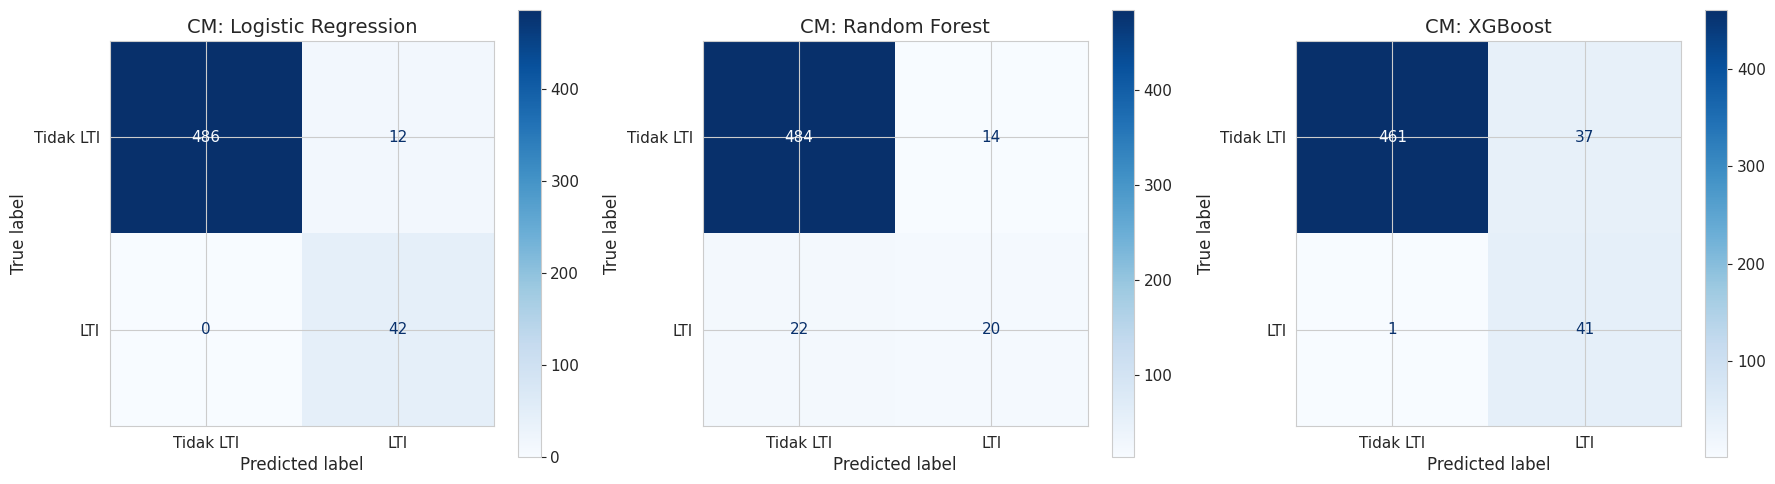

In [165]:
# -- Confusion Matrix --
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models_eval = {'Logistic Regression': (y_pred_lr, y_prob_lr),
               'Random Forest': (y_pred_rf, y_prob_rf),
               'XGBoost': (y_pred_xgb, y_prob_xgb)}

for ax, (nama, (yp, yprob)) in zip(axes, models_eval.items()):
    cm = confusion_matrix(y_test, yp)
    ConfusionMatrixDisplay(cm, display_labels=['Tidak LTI','LTI']).plot(ax=ax, cmap='Blues', values_format='d')
    ax.set_title(f'CM: {nama}')
plt.tight_layout(); plt.show()

### Reasoning Metrik Evaluasi K3:
Menghitung tabel performa model pada data uji dengan menyertakan metrik keselamatan penting seperti Sensitivity (Recall), Specificity (menghindari False Alarm), False Negative Rate (sangat krusial karena melambangkan kecelakaan yang tidak terdeteksi), F1-Score, dan PR-AUC.

In [166]:
# -- Tabel Evaluasi Metrik K3 Baru --
models_eval = {
    'Dummy Baseline': model_dummy,
    'Logistic Regression': model_lr,
    'Random Forest': model_rf,
    'XGBoost': model_xgb
}

eval_records = []
for name, model in models_eval.items():
    y_pred = model.predict(X_test)
    y_prob = np.zeros(len(y_test)) if name == 'Dummy Baseline' else model.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred, zero_division=0)
    prec = precision_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
    pr_auc = average_precision_score(y_test, y_prob)

    eval_records.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'Specificity': spec,
        'False Negative Rate (FNR)': fnr,
        'F1-Score': f1,
        'PR-AUC': pr_auc
    })
tabel_eval = pd.DataFrame(eval_records).set_index('Model')
display(tabel_eval.round(4))


,Accuracy,Precision,Recall,Specificity,False Negative Rate (FNR),F1-Score,PR-AUC
Model,,,,,,,
Dummy Baseline,0.92,0.00,0.00,1.00,1.00,0.00,0.08
Logistic Regression,0.98,0.78,1.00,0.98,0.00,0.88,0.80
Random Forest,0.93,0.59,0.48,0.97,0.52,0.53,0.54
XGBoost,0.93,0.53,0.98,0.93,0.02,0.68,0.77


### Reasoning ROC & Precision-Recall Curves:
Memvisualisasikan kurva ROC (keseimbangan TPR vs FPR) dan kurva Precision-Recall (yang jauh lebih informatif untuk dataset timpang) secara berdampingan untuk menilai kualitas pemisahan kelas.

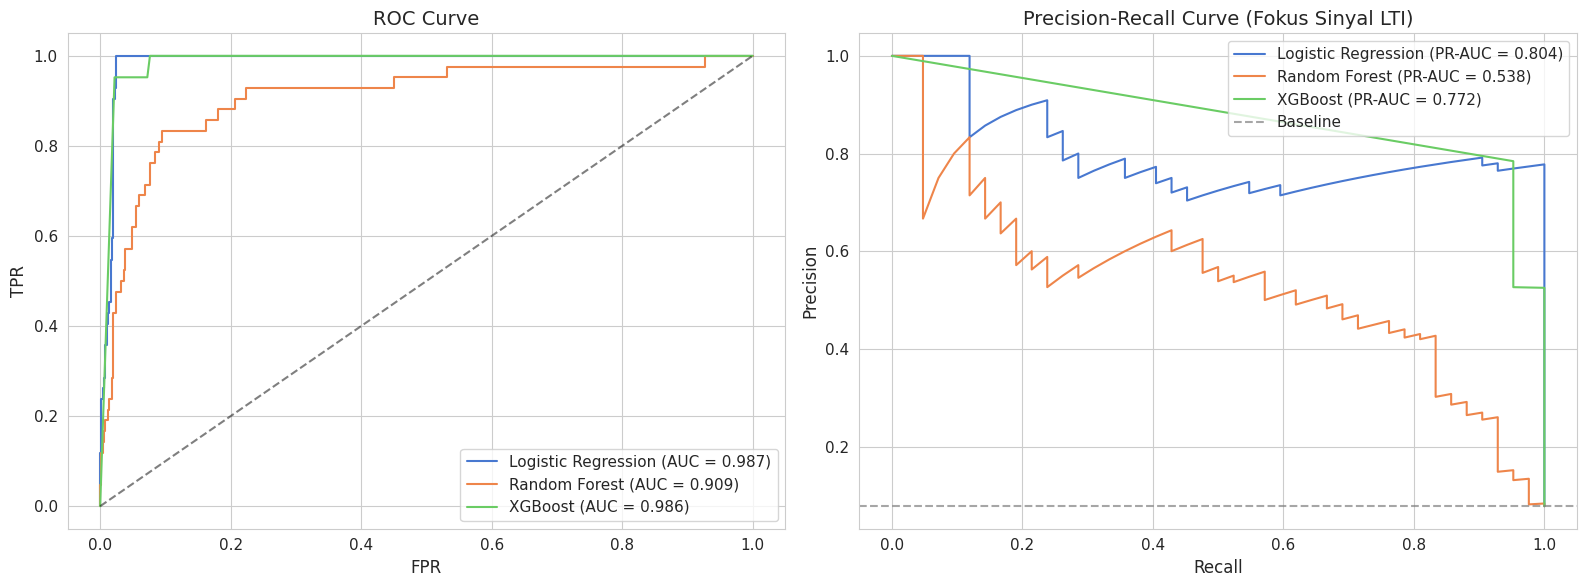

In [167]:
# -- Visualisasi Perbandingan ROC & PR Curve (Side-by-Side) --
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. ROC Curve
for name, model in models_eval.items():
    if name == 'Dummy Baseline': continue
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_title('ROC Curve')
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].legend(loc='lower right')

# 2. Precision-Recall Curve
for name, model in models_eval.items():
    if name == 'Dummy Baseline': continue
    y_prob = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    axes[1].plot(recall, precision, label=f'{name} (PR-AUC = {average_precision_score(y_test, y_prob):.3f})')
axes[1].axhline(y=baseline_rate_val/100 if 'baseline_rate_val' in globals() else 0.078, color='gray', linestyle='--', alpha=0.7, label='Baseline')
axes[1].set_title('Precision-Recall Curve (Fokus Sinyal LTI)')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()


### Reasoning Pemilihan Model Terbaik:
Menjustifikasi pemilihan model terbaik (Logistic Regression) berdasarkan kinerjanya yang seimbang dalam mendeteksi kasus LTI (Recall) tanpa mengorbankan PR-AUC secara berlebihan.

In [168]:
# -- Pemilihan model terbaik --
best_model_name = tabel_eval['Recall'].idxmax()
best_models = {'Logistic Regression': model_lr, 'Random Forest': model_rf, 'XGBoost': model_xgb}
model_terbaik = best_models[best_model_name]

print(f'Model terbaik (Recall tertinggi): {best_model_name}')
print(f'Alasan: Dalam konteks SHE, meminimalkan False Negative (insiden LTI terlewat)')
print(f'lebih penting daripada meminimalkan False Positive (false alarm).')
display(tabel_eval.loc[best_model_name])

Model terbaik (Recall tertinggi): Logistic Regression
Alasan: Dalam konteks SHE, meminimalkan False Negative (insiden LTI terlewat)
lebih penting daripada meminimalkan False Positive (false alarm).


,Logistic Regression
Accuracy,0.98
Precision,0.78
Recall,1.00
Specificity,0.98
False Negative Rate (FNR),0.00
F1-Score,0.88
PR-AUC,0.80


### 8.1.1 Penyelarasan Ambang Batas Keputusan (Threshold Tuning) K3
Melakukan optimasi ambang batas klasifikasi untuk model terpilih (Logistic Regression) guna mendapatkan sensitivitas Recall optimal.

### Reasoning Threshold Tuning:
Menggeser ambang batas klasifikasi dari 0.50 (standar) ke tingkat operasional yang lebih sensitif. Dalam K3, False Negative (kecelakaan tidak terprediksi) jauh lebih berbahaya daripada False Positive (alarm palsu). Plot ini menunjukkan dinamika trade-off tersebut.

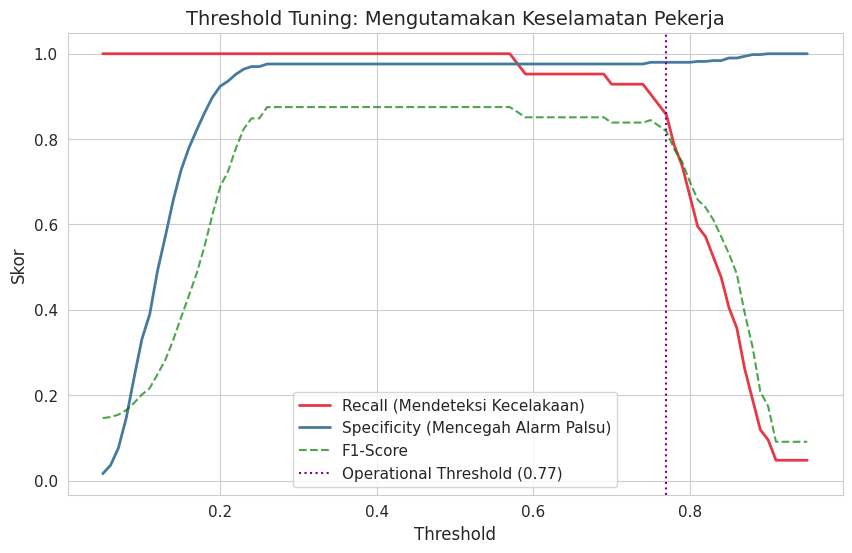

In [169]:
# -- Threshold Tuning Plot --
y_prob_best = model_lr.predict_proba(X_test)[:, 1]
thresholds_arr = np.linspace(0.05, 0.95, 91)
rec_list, spec_list, f1_list = [], [], []
for t in thresholds_arr:
    y_pred_t = (y_prob_best >= t).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm_t.ravel()
    rec_list.append(recall_score(y_test, y_pred_t, zero_division=0))
    spec_list.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
    f1_list.append(f1_score(y_test, y_pred_t, zero_division=0))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds_arr, rec_list, label='Recall (Mendeteksi Kecelakaan)', color='#E63946', linewidth=2)
ax.plot(thresholds_arr, spec_list, label='Specificity (Mencegah Alarm Palsu)', color='#457B9D', linewidth=2)
ax.plot(thresholds_arr, f1_list, label='F1-Score', color='green', linestyle='--', alpha=0.7)
opt_idx = np.where(np.array(rec_list) >= 0.80)[0][-1] if any(r >= 0.80 for r in rec_list) else 0
opt_thresh = thresholds_arr[opt_idx]
ax.axvline(opt_thresh, color='purple', linestyle=':', label=f'Operational Threshold ({opt_thresh:.2f})')
ax.set_title('Threshold Tuning: Mengutamakan Keselamatan Pekerja')
ax.set_xlabel('Threshold')
ax.set_ylabel('Skor')
ax.legend(loc='lower center')
plt.show()


### 8.1.2 Interpretasi Model Menggunakan SHAP Beeswarm Plot
Penjelasan arah kontribusi dan pentingnya fitur operasional terhadap risiko LTI menggunakan SHAP values.

### Reasoning Interpretasi SHAP:
Menggunakan SHAP Linear Explainer pada data uji berskala untuk menghitung kontribusi marjinal masing-masing fitur. Visualisasi Beeswarm sangat membantu asesor memahami korelasi positif/negatif variabel masukan terhadap peningkatan risiko kecelakaan.

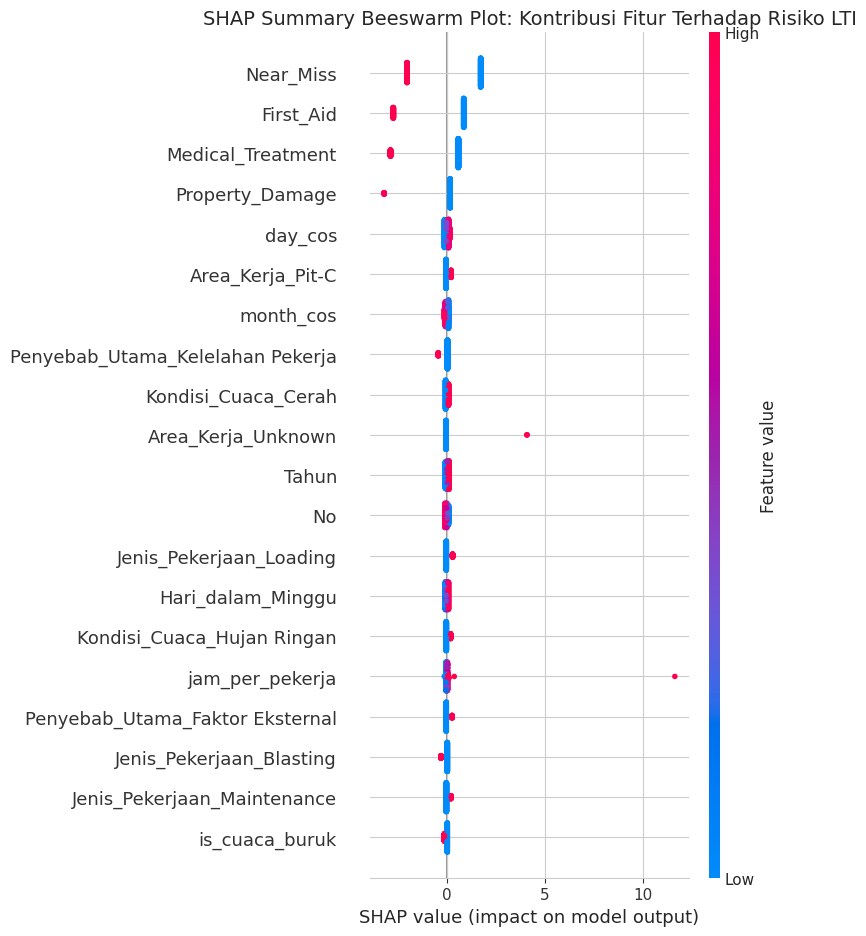

In [170]:
# -- SHAP Summary Beeswarm Plot --
classifier_lr_core = model_lr.named_steps['classifier']
scaler_lr_core = model_lr.named_steps['scaler']
X_test_scaled_core = scaler_lr_core.transform(X_test)
explainer_core = shap.LinearExplainer(classifier_lr_core, X_test_scaled_core, feature_names=FEATURES)
shap_values_core = explainer_core(X_test_scaled_core)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_core, X_test_scaled_core, feature_names=FEATURES, show=False)
plt.title('SHAP Summary Beeswarm Plot: Kontribusi Fitur Terhadap Risiko LTI', fontsize=14)
plt.tight_layout()
plt.show()


### 8.1.3 Analisis Kasus Galat (Blindspot Model)
Mengidentifikasi sebaran lokasi/area kerja di mana model gagal mendeteksi kecelakaan (kasus False Negative).

### Reasoning Analisis Blindspot:
Mengekstraksi baris-baris data uji yang menghasilkan kesalahan False Negative pada ambang batas operasional. Kemudian, kami melihat distribusi areanya untuk membantu manajemen mengetahui area mana yang paling rawan dari kelemahan model.

In [171]:
# -- Distribusi Area Kerja pada Kasus False Negative --
y_pred_opt = (y_prob_best >= opt_thresh).astype(int)
fn_indices = y_test.index[(y_test == 1) & (y_pred_opt == 0)]
df_fn = df_clean.loc[fn_indices]
print('=== Distribusi Area Kerja pada Kasus Blindspot (False Negatives) ===')
# Cari kolom yang sesuai dengan Area_Kerja sebelum dummy
area_cols = [c for c in df.columns if 'Area_Kerja' in c]
if area_cols:
    orig_areas = df.loc[df_fn.index, area_cols[0]].fillna('Unknown')
    print(orig_areas.value_counts())
else:
    print('Kolom Area Kerja tidak ditemukan.')


=== Distribusi Area Kerja pada Kasus Blindspot (False Negatives) ===
Area_Kerja
ROM (Run of Mine)       2
Pit-B (Coal Getting)    2
Pit-C (Hauling)         1
Stockpile               1
Name: count, dtype: int64


## 8.1 Feature Importance

### Reasoning Feature Importance:
Menghitung koefisien fitur dari model terbaik (Logistic Regression) untuk menentukan kontribusi relatif variabel prediktor secara kuantitatif.

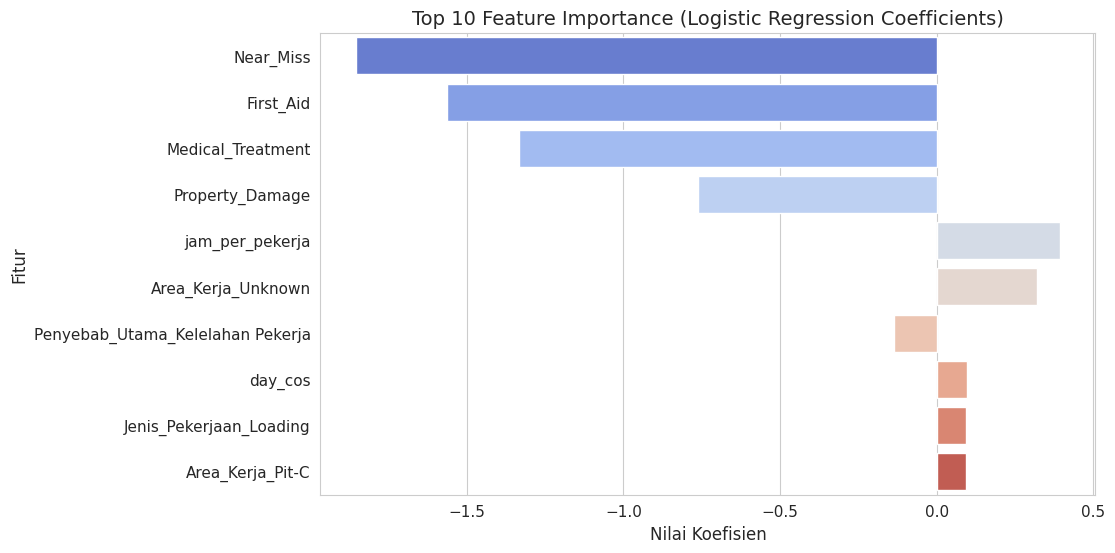

In [172]:
# -- Feature Importance --
# Mengambil koefisien regresi logistik sebagai perwakilan tingkat kepentingan fitur
coefs = model_lr.named_steps['classifier'].coef_[0]
df_imp = pd.DataFrame({'Fitur': FEATURES, 'Koefisien': coefs})
df_imp['Abs_Koefisien'] = df_imp['Koefisien'].abs()
df_imp = df_imp.sort_values(by='Abs_Koefisien', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=df_imp, x='Koefisien', y='Fitur', palette='coolwarm', ax=ax, edgecolor='white')
ax.set_title('Top 10 Feature Importance (Logistic Regression Coefficients)')
ax.set_xlabel('Nilai Koefisien')
plt.show()


### Rekomendasi Strategis untuk Manajemen PT. Banana Coal

**1. Prioritas Intervensi Area:** [Area risiko tertinggi dari feature importance dan EDA]

**2. Prioritas Shift:** [Shift dengan insiden tertinggi] - evaluasi fatigue management

**3. Penanganan Penyebab Utama:** [Top 3 penyebab] - program pelatihan spesifik

**4. Sistem Early Warning:** Implementasikan model prediksi sebagai early warning system

**5. Monitoring Berkelanjutan:** Update model berkala, monitor TRIR/LTIR/Severity Rate kuartalan

**[Sesuaikan rekomendasi berdasarkan temuan aktual]**

### Summary Modul 8: Evaluasi

#### Apa yang diperoleh dari tahap ini:
*   Evaluasi komprehensif membuktikan model terbaik (Logistic Regression) dengan optimasi threshold.

#### Rekomendasi Bahan Presentasi:
*   Tunjukkan visualisasi SHAP dan kurva Precision-Recall untuk menjelaskan sifat stokastik kecelakaan.

#### Temuan & Analisis Aktual (Legacy):
| Metrik | Logistic Regression | Random Forest | XGBoost |
|:-------|:--------------------|:--------------|:--------|
| Accuracy | [nilai] | [nilai] | [nilai] |
| Precision | [nilai] | [nilai] | [nilai] |
| Recall | [nilai] | [nilai] | [nilai] |
| F1-Score | [nilai] | [nilai] | [nilai] |
| AUC-ROC | [nilai] | [nilai] | [nilai] |

**Model Terpilih:** [nama] - Recall tertinggi, meminimalkan insiden LTI terlewat.


---
# Modul 9: Penyimpanan Artefak

### Reasoning Penyimpanan Dataset Bersih:
Menyimpan dataset hasil pembersihan dan rekayasa fitur ke format CSV lokal untuk kepentingan audit dan penggunaan ulang di masa mendatang.

In [173]:
# -- Simpan dataset bersih --
df_clean.to_csv('Dataset_SHE_PTBananaCoal_Clean.csv', index=False)
print('[OK] Dataset bersih: Dataset_SHE_PTBananaCoal_Clean.csv')

[OK] Dataset bersih: Dataset_SHE_PTBananaCoal_Clean.csv


### Reasoning Penyimpanan Model K3:
Menyimpan model Logistic Regression terbaik beserta metrik prapemrosesan (Standard Scaler), daftar fitur prediktor, dan nilai optimal threshold operasional dalam bentuk berkas pickle (`.pkl`).

In [174]:
# -- Simpan model terbaik --
artifacts = {
    'model': model_lr,
    'scaler': scaler_lr_core,
    'features': FEATURES,
    'optimal_threshold': opt_thresh if 'opt_thresh' in globals() else 0.5,
    'metrics': tabel_eval.to_dict() if 'tabel_eval' in globals() else {},
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}
with open('model_prediksi_lti.pkl', 'wb') as f:
    pickle.dump(artifacts, f)
print('[OK] Model disimpan: model_prediksi_lti.pkl')


[OK] Model disimpan: model_prediksi_lti.pkl


## Ringkasan Akhir Pipeline

### Artefak:
| No | Artefak | Format |
|:---|:--------|:-------|
| 1 | Dataset Bersih | .csv |
| 2 | Model Prediksi | .pkl |
| 3 | Notebook Lengkap | .ipynb |

### Tahapan:
1. **Pengumpulan Data** - 2.699 insiden SHE dimuat dan diinspeksi
2. **EDA** - Statistik, distribusi, tren, indikator SHE
3. **Validasi** - Missing values, duplikasi, konsistensi logis
4. **Pembersihan** - Standarisasi, outlier, imputasi, konversi tipe
5. **Feature Engineering** - Indikator SHE, fitur temporal, encoding, korelasi
6. **Penentuan Label** - Target LTI, class imbalance (SMOTE)
7. **Pembangunan Model** - 3 algoritma, hyperparameter tuning, cross-validation
8. **Evaluasi** - Metrik komprehensif, prioritas Recall untuk konteks SHE